<a id="kalshi-market-time-series-construction"></a>
# Kalshi Market Time Series Construction
Process all markets & trades parquet files to build bid-ask spread and last price time series.

## Table of contents

1. [Milestone 2 - EDA](#kalshi-market-time-series-construction)
2. [Milestone 3 — Baseline Model](#milestone-eda-features)


In [ ]:
import pandas as pd
import numpy as np
import glob
import os
from pathlib import Path
import matplotlib.pyplot as plt
import fastparquet


REPO_ROOT = Path(__file__).resolve().parent.parent if "__file__" in dir() else Path.cwd().parent
PATH = REPO_ROOT / "data" / "kalshi"
MARKETS_DIR = PATH / "markets"
TRADES_DIR = PATH / "trades"
OUTPUT_DIR = PATH / "processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

market_files = sorted(MARKETS_DIR.glob("*.parquet"))
trade_files = sorted(TRADES_DIR.glob("*.parquet"))
print(f"Market files: {len(market_files)}, Trade files: {len(trade_files)}")

## Process Markets — extract bid/ask/spread/last_price per ticker over time
We process in chunks to avoid OOM, keeping only the columns we need.

In [ ]:
MARKET_COLS = ["ticker", "yes_bid", "yes_ask", "no_bid", "no_ask", "last_price", "open_time", "close_time", "status", "volume"]

chunks = []
for i, f in enumerate(market_files):
    trade_ts = pd.read_parquet(f, columns=MARKET_COLS)
    chunks.append(trade_ts)
    if (i + 1) % 100 == 0:
        print(f"  loaded {i+1}/{len(market_files)} market files")

markets = pd.concat(chunks, ignore_index=True)
del chunks
print(f"Total market rows: {len(markets):,}")
markets.head()

In [ ]:
# Compute spreads
markets["yes_spread"] = markets["yes_ask"] - markets["yes_bid"]
markets["no_spread"] = markets["no_ask"] - markets["no_bid"]

# Parse times
markets["open_time"] = pd.to_datetime(markets["open_time"], utc=True)
markets["close_time"] = pd.to_datetime(markets["close_time"], utc=True)

markets.head()

In [ ]:
# Save full processed markets table
markets.to_parquet(os.path.join(OUTPUT_DIR, "all_markets.parquet"), index=False)
print("Saved all_markets.parquet")

# Check that yes and no prices are consistent

In [ ]:
trades = pd.read_parquet(os.path.join(OUTPUT_DIR, "all_trades.parquet"))

trades.head()


In [ ]:
trades["arb"] = (trades["yes_price"] + trades["no_price"] != 100).astype(int)
count_arb = trades["arb"].sum()/len(trades)*100
print(f"Number of arbitrage trades: {count_arb}")


arb_df = trades[trades["arb"] == 1]

arb_df.head()

In [ ]:
arb_df["arb_amount"] = 100 - (arb_df["yes_price"] + arb_df["no_price"])
arb_df["arb_amount"].describe()

Given that all the inconsistencies are 1.0, its probably due to rounding errors; Note that the actual Kalshi prices can be decimal points when nearing ends

- so can remove no price as it is a linear combination of yes price

In [ ]:
# remove no_price from trades to save space
trades.drop(columns=["no_price"], inplace=True)
trades.head()

# Quick summary stats & sanity checks

In [ ]:
# Load processed data
markets = pd.read_parquet(os.path.join(OUTPUT_DIR, "all_markets.parquet"))
trades = pd.read_parquet(os.path.join(OUTPUT_DIR, "all_trades.parquet"))

trades.head()


In [ ]:
print("\n=== Trades ===")
print(f"Unique tickers traded: {trades['ticker'].nunique():,}")
print(f"Date range: {trades['created_time'].min()} -> {trades['created_time'].max()}")
print(f"Total number of trades: {len(trades):,}")
print(f"Yes price stats:")
print(trades["yes_price"].describe())

In [ ]:
top_ticker = trades.groupby("ticker").size().idxmax()
print(f"Most traded ticker: {top_ticker}")

ts = trades[trades["ticker"] == top_ticker].set_index("created_time").sort_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(ts.index, ts["yes_price"], lw=0.8)
axes[0].set_ylabel("Yes Price (cents)")
axes[0].set_title(f"{top_ticker} — Last Trade Price")

# Resample volume to hourly so bar chart has far fewer bars
volume = np.where(ts["taker_side"] == "yes",
                  ts["count"] * ts["yes_price"],
                  ts["count"] * ts["no_price"])

volume = pd.Series(volume, index=ts.index).resample("1h").sum()

axes[1].bar(volume.index, volume.values, width=0.03, alpha=0.7)
axes[1].set_ylabel("# Trades (hourly)")
axes[1].set_title("Trade Volume")

plt.tight_layout()
plt.show()



In [ ]:
# add volume as a feature
trades["volume"] = np.where(trades["taker_side"] == "yes",
                            trades["count"] * trades["yes_price"],
                            trades["count"] * (100-trades["yes_price"]))/100 # convert to dollars
trades.head()

### Liquidity metrics

In [ ]:
# Distribution of last_yes_price
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(trades["yes_price"], bins=100, edgecolor="none", alpha=0.7)
axes[0, 0].set_title("Distribution of Last Yes Price")
axes[0, 0].set_xlabel("Price (cents)")

axes[0, 1].hist(trades["volume"].clip(upper=trades["volume"].quantile(0.99)), bins=100, edgecolor="none", alpha=0.7)
axes[0, 1].set_title("Distribution of Volume per Trade (clipped 99th pct)")
axes[0, 1].set_xlabel("Volume (dollars)")

# Trades per day
daily = trades.groupby(trades["created_time"].dt.date)["volume"].sum()
axes[1, 0].plot(daily.index, daily.values, lw=0.5)
axes[1, 0].set_title("Volume per Day (dollars)")
axes[1, 0].tick_params(axis="x", rotation=45)

# Active tickers per day
active = trades.groupby(trades["created_time"].dt.date)["ticker"].nunique()
axes[1, 1].plot(active.index, active.values, lw=0.5)
axes[1, 1].set_title("Active Tickers per Day")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Filtering poor contracts
### Do not want poor data from illiquid contracts
- At first wanted to filter by number of a contract
    - However this introduces lookahead bias
- Decided to cut by timestamp, since Kalshi was not heavily used before a certain point


In [ ]:
# Find the first day with > 10M daily volume
daily_volume = trades.groupby(trades["created_time"].dt.date)["volume"].sum()
first_10m = daily_volume[daily_volume > 10000000].index[0]
print(f"First day with > 10M volume: {first_10m}")
original_rows = len(trades)
# Fix: convert date -> UTC-aware Timestamp for comparison
first_10m_ts = pd.Timestamp(first_10m, tz='UTC')


# Remove all trades before this date as well
original_rows = len(trades)
trades = trades[trades["created_time"] >= first_10m_ts].reset_index(drop=True)
print(f"Rows after removing early trades: {original_rows:,} -> {len(trades):,} rows")

In [ ]:
# Distribution of last_yes_price
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(trades["yes_price"], bins=100, edgecolor="none", alpha=0.7)
axes[0, 0].set_title("Distribution of Last Yes Price")
axes[0, 0].set_xlabel("Price (cents)")

axes[0, 1].hist(trades["volume"].clip(upper=trades["volume"].quantile(0.99)), bins=100, edgecolor="none", alpha=0.7)
axes[0, 1].set_title("Distribution of Volume per Trade (clipped 99th pct)")
axes[0, 1].set_xlabel("Volume (dollars)")

# Trades per day
daily = trades.groupby(trades["created_time"].dt.date)["volume"].sum()
axes[1, 0].plot(daily.index, daily.values, lw=0.5)
axes[1, 0].set_title("Volume per Day (dollars)")
axes[1, 0].tick_params(axis="x", rotation=45)

# Active tickers per day
active = trades.groupby(trades["created_time"].dt.date)["ticker"].nunique()
axes[1, 1].plot(active.index, active.values, lw=0.5)
axes[1, 1].set_title("Active Tickers per Day")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# Misc

In [ ]:
last_price_per_ticker = (
    trades.sort_values("created_time")
            .groupby("ticker")[("yes_price")]
            .last()
)

plt.figure(figsize=(10, 6))
plt.hist(last_price_per_ticker, bins=100, edgecolor="none", alpha=0.7)
plt.title("Distribution of Final Traded Price per Ticker")
plt.xlabel("Final Yes Price (cents)")
plt.ylabel("Number of Tickers")
plt.tight_layout()
plt.show()

print(last_price_per_ticker.describe())
print(f"\nTickers ending 0-5 cents:   {(last_price_per_ticker <= 5).sum():,}")
print(f"Tickers ending 95-100 cents: {(last_price_per_ticker >= 95).sum():,}")
print(f"Tickers in between:          {((last_price_per_ticker > 5) & (last_price_per_ticker < 95)).sum():,}")

In [ ]:
vol_per_ticker = trades.groupby("ticker")["volume"].sum()

fig, ax = plt.subplots(figsize=(10, 5))  # just 1 subplot

ax.hist(vol_per_ticker, bins=100, edgecolor="none", alpha=0.7, log=True)
ax.set_title("Approx Volume per Ticker (log scale)")
ax.set_xlabel("Volume (cents)")
ax.set_ylabel("Number of Tickers")

plt.tight_layout()
plt.show()

print(vol_per_ticker.describe())

## How do we classify a large jump?

There are many ways we have found to defined a target
- Continous: Predict direction and magnitude of jumps
- Binary Classification: Predict whether a shock will happen (1) or not (0)
- Multiclass Classification: Predict whether a shock will occur upwards (1), downwards (-1), or not occur (0)

In [ ]:
# Sort by time only (not ticker first)
trades = trades.sort_values('created_time').reset_index(drop=True)

past = (
    trades[['ticker', 'created_time', 'yes_price']]
    .copy()
    .rename(columns={'yes_price': 'yes_price_15m_ago'})
)
past['created_time'] = past['created_time'] + pd.Timedelta('15min')
past = past.sort_values('created_time').reset_index(drop=True)

merged = pd.merge_asof(
    trades,
    past,
    on='created_time',
    by='ticker',
    direction='backward'
)

merged['return_15min'] = (
    (merged['yes_price'] - merged['yes_price_15m_ago'])
    / merged['yes_price_15m_ago']
)

trades = merged
display(trades.head())
print(f"Non-null 15min returns: {trades['return_15min'].notna().sum():,}")

In [ ]:
returns = trades['return_15min'].replace([np.inf, -np.inf], np.nan).dropna()

# Optional: clip extreme outliers for visualization
returns_clipped = returns.clip(returns.quantile(0.01), returns.quantile(0.99))

plt.figure(figsize=(10, 6))
plt.hist(returns_clipped, bins=100, edgecolor='none', alpha=0.7)
plt.title("Distribution of 15-Minute Returns (1st-99th pct)")
plt.xlabel("15-Minute Return")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(returns.describe())
print(f"\nInf values removed: {(trades['return_15min'] == np.inf).sum():,}")
print(f"Zero base prices:   {(trades['yes_price_15m_ago'] == 0).sum():,}")

In [ ]:
print(f"Kurtosis: {returns.kurtosis():.2f}")
print(f"Skewness: {returns.skew():.2f}")

what happens if we take away all the trades that are close to the edge cases?
i.e. price is 0-0.05 and 0.95-1

In [ ]:
OG = len(trades)
mask = trades["yes_price_15m_ago"] >= 3
trades = trades.loc[mask].reset_index(drop=True)
del mask
print(f"Rows after removing small base prices: {OG:,} -> {len(trades):,}")

returns = trades['return_15min'].replace([np.inf, -np.inf], np.nan).dropna()
returns_clipped = returns.clip(returns.quantile(0.01), returns.quantile(0.99))

plt.figure(figsize=(10, 6))
plt.hist(returns_clipped, bins=100, edgecolor='none', alpha=0.7)  # use returns_clipped or returns
plt.title("Distribution of 15-Minute Returns (1st-99th pct)")
plt.xlabel("15-Minute Return")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(returns.describe())
print(f"\nInf values removed: {(trades['return_15min'] == np.inf).sum():,}")
print(f"Zero base prices:   {(trades['yes_price_15m_ago'] == 0).sum():,}")

In [ ]:
print(f"Kurtosis: {returns.kurtosis():.2f}")
print(f"Skewness: {returns.skew():.2f}")

## Absolute returns

In [ ]:
trades = trades.sort_values('created_time').reset_index(drop=True)

# Drop stale column if it exists from a previous run
trades = trades.drop(columns=['yes_price_15m_ago', 'return_15min'], errors='ignore')

past = (
    trades[['ticker', 'created_time', 'yes_price']]
    .copy()
    .rename(columns={'yes_price': 'yes_price_15m_ago'})
)
past['created_time'] = past['created_time'] + pd.Timedelta('15min')
past = past.sort_values('created_time').reset_index(drop=True)

merged = pd.merge_asof(
    trades,
    past,
    on='created_time',
    by='ticker',
    direction='backward'
)

merged['return_15min'] = merged['yes_price'] - merged['yes_price_15m_ago']

trades = merged
display(trades.head())
print(f"Non-null 15min returns: {trades['return_15min'].notna().sum():,}")

In [ ]:
returns = trades['return_15min'].replace([np.inf, -np.inf], np.nan).dropna()

# Optional: clip extreme outliers for visualization
returns_clipped = returns.clip(returns.quantile(0.01), returns.quantile(0.99))

plt.figure(figsize=(10, 6))
plt.hist(returns_clipped, bins=100, edgecolor='none', alpha=0.7)
plt.title("Distribution of 15-Minute Returns (1st-99th pct)")
plt.xlabel("15-Minute Return")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(returns.describe())
print(f"\nInf values removed: {(trades['return_15min'] == np.inf).sum():,}")
print(f"Zero base prices:   {(trades['yes_price_15m_ago'] == 0).sum():,}")

In [ ]:
print("Kurtosis: {:.2f}".format(returns.kurtosis()))
print("Skewness: {:.2f}".format(returns.skew()))

In [ ]:
start_date = pd.Timestamp('2024-11-05', tz='UTC')
end_date   = pd.Timestamp('2024-11-06', tz='UTC')

djt = (
    trades[
        (trades["ticker"] == "PRES-2024-DJT") &
        (trades["created_time"] >= start_date) &
        (trades["created_time"] <= end_date)
    ]
    .sort_values("created_time")
)

plt.figure(figsize=(14, 5))
plt.plot(djt["created_time"], djt["return_15min"], lw=0.8, alpha=0.8)
plt.axhline(0, color="red", lw=0.5, linestyle="--")
plt.title(f"PRES-2024-DJT — 15-Minute Absolute Returns ({start_date.date()} to {end_date.date()})")
plt.xlabel("Time")
plt.ylabel("Abs Return (cents)")
plt.tight_layout()
plt.show()

print(djt["return_15min"].describe())

In [ ]:
returns_jump_up = returns.quantile(0.75)
returns_jump_down = returns.quantile(0.25)
print(f"75th percentile return (jump up): {returns_jump_up:.2f} cents")
print(f"25th percentile return (jump down): {returns_jump_down:.2f} cents")

In [ ]:
conditions = [
    trades["return_15min"] >= returns_jump_up,
    trades["return_15min"] <= returns_jump_down,
]
choices = [1, -1]
trades["y"] = np.select(conditions, choices, default=0)

In [ ]:
trades.tail()

In [ ]:

np.random.seed(42)

unique_tickers = trades["ticker"].unique()
sampled_tickers = np.random.choice(unique_tickers, size=5, replace=False)

for tkr in sampled_tickers:
    sub = (
        trades[trades["ticker"] == tkr]
        .sort_values("created_time")
    )

    fig, ax1 = plt.subplots(figsize=(14, 5))

    # Price on the left axis — shows the full history
    ax1.plot(sub["created_time"], sub["yes_price"],
             lw=0.6, alpha=0.5, color="gray", label="yes_price")
    ax1.set_xlabel("Time")
    ax1.set_ylabel("yes_price (cents)", color="gray")
    ax1.tick_params(axis="y", labelcolor="gray")

    # Overlay jump-up / jump-down markers
    jumps_up = sub[sub["y"] == 1]
    jumps_dn = sub[sub["y"] == -1]
    ax1.scatter(jumps_up["created_time"], jumps_up["yes_price"],
                s=12, color="green", alpha=0.7, label="Jump Up")
    ax1.scatter(jumps_dn["created_time"], jumps_dn["yes_price"],
                s=12, color="red", alpha=0.7, label="Jump Down")

    # Let matplotlib auto-scale to the full time range of this ticker
    ax1.set_xlim(sub["created_time"].min(), sub["created_time"].max())

    ax1.set_title(f"{tkr} — Full History with Jump Labels "
                  f"({sub['created_time'].min().date()} → {sub['created_time'].max().date()}, "
                  f"n={len(sub):,})")
    ax1.legend(loc="best")
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

In [ ]:
trades.head()

In [ ]:
trades.to_parquet(os.path.join(OUTPUT_DIR, "trades_with_labels.parquet"), index=False)
print("Saved trades_with_labels.parquet")

In [ ]:
len(trades)

## `trades` DataFrame — Schema & Description

A time-ordered record of individual trade executions on prediction-market contracts, enriched with a 15-minute lookback return and a discrete jump label.

### Columns

| Column | dtype | Description |
|---|---|---|
| `ticker` | `string` | Contract identifier, for example `PRES-2024-KH`, `PRES-2024-DJT`, or `POPVOTE-24-R`. Groups rows into per-market time series |
| `yes_price` | `int` (cents) | Price of the YES side of the contract at the time of the trade, in cents from 0 to 100. Interpretable as the implied probability of the event resolving YES |
| `no_price` | `int` (cents) | Price of the NO side, equal to `100 - yes_price`. Redundant with `yes_price` but included for convenience |
| `count` | `int` | Number of contracts traded in this execution |
| `taker_side` | `string` | Side of the aggressor. `"yes"` means the taker bought YES by lifting offers, while `"no"` means the taker bought NO by hitting bids. Useful as an order-flow signal |
| `created_time` | `datetime64[ns, UTC]` | Timestamp of the trade in UTC, with microsecond precision. Used as the time index for sorting and resampling |
| `volume` | `float` (dollars) | Notional trade size in dollars, computed as `count × yes_price / 100` |
| `yes_price_15m_ago` | `float` (cents) | The `yes_price` observed approximately 15 minutes earlier for the same `ticker`. `NaN` for rows within the first 15 minutes of that ticker’s history |
| `return_15min` | `float` (cents) | Price change over the prior 15 minutes, computed as `yes_price - yes_price_15m_ago`. `NaN` where a 15-minute prior price is unavailable |
| `y` | `int ∈ {-1, 0, 1}` | Jump label derived from `return_15min` quantiles across all non-`NaN` returns. `1` if `return_15min ≥ 75th` percentile, `-1` if `return_15min ≤ 25th` percentile, and `0` otherwise. Rows with `NaN` returns are assigned `0` |

### Key Properties

- **Sort order:** Rows are chronological across all tickers. Within each ticker, ordering is also time-ascending after `.sort_values("created_time")`
- **Granularity:** One row per executed trade, not aggregated bars, so inter-trade spacing is irregular
- **Label balance:** By construction, `y == 1` and `y == -1` each account for about 25% of labeled rows, while `y == 0` accounts for about 50%
- **Coverage window:** Spans from the first observed trade, for example `2024-10-25 00:15:29 UTC`, through the end of the data pull. Per-ticker ranges vary depending on listing and resolution dates

<a id="milestone3-preprocessing"></a>
## Milestone 3 - Baseline Model

We build a full pipeline including forward-return computation, temporal coherence checks on input windows, and a precision-optimised decision threshold on top of the CNN output.

**We work through 8 steps:**
1. Setup - environment, imports, config
2. Build Bars - load trades, filter, aggregate
3. Features & Labels
4. Validate & Visualise - distribution plots
5. Save / Load Dataset - `bars_clean.parquet` checkpoint
6. Train / Load CNNs - training with checkpoint skip, inference helpers, threshold search
7. Prediction Analysis - price distribution, most-confident case studies
8. Interpretability - saliency maps, feature ablation

### Step 1 - Setup

We mount Google Drive when running in Colab, then import all libraries and centralise every hyperparameter in `CFG`.

In [3]:
# -- 0. Environment Setup ------------------------------------------------------
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    %pip install -q pyarrow pandas numpy matplotlib
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_DIR = '/content/drive/MyDrive/CS1090B/project'
else:
    from pathlib import Path
    PROJECT_DIR = str(Path.cwd().resolve())

import os
PROCESSED_DIR = os.path.join(PROJECT_DIR, 'data', 'kalshi', 'processed')
TRADES_PATH   = os.path.join(PROCESSED_DIR, 'trades_with_labels.parquet')
OUTPUT_PATH   = os.path.join(PROCESSED_DIR, 'bars_clean.parquet')

print(f'PROCESSED_DIR : {PROCESSED_DIR}')
print(f'Trades file   : {TRADES_PATH}')
print(f'Output file   : {OUTPUT_PATH}')
assert os.path.exists(TRADES_PATH), 'trades_with_labels.parquet not found!'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROCESSED_DIR : /content/drive/MyDrive/CS1090B/project/data/kalshi/processed
Trades file   : /content/drive/MyDrive/CS1090B/project/data/kalshi/processed/trades_with_labels.parquet
Output file   : /content/drive/MyDrive/CS1090B/project/data/kalshi/processed/bars_clean.parquet


In [1]:
# -- 1. Imports & Config -------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gc

CFG = {
    # Prediction horizons in minutes - labels are computed for each
    'horizons_min': [5, 15, 30, 60],

    # Jump threshold: symmetric percentiles of the forward return distribution
    #   0.25 / 0.75  ->  50% of bars labeled as jumps (original, very permissive)
    #   0.10 / 0.90  ->  20% of bars labeled as jumps (recommended starting point)
    #   0.05 / 0.95  ->  10% of bars labeled as jumps (only strong moves)
    'jump_pct_low':  0.10,
    'jump_pct_high': 0.90,

    # Bar frequency
    'bar_freq': '1min',

    # Drop tickers with fewer than this many raw trades (too sparse to learn from)
    'min_trades_per_ticker': 50,

    # Temporal split fractions (must sum to 1.0)
    'train_frac': 0.70,
    'val_frac':   0.15,
    # test_frac = 1 - train_frac - val_frac = 0.15
}

### Step 2 — Build 1-Minute Bars

We load raw columns only, drop tickers with fewer than `min_trades_per_ticker` trades, then aggregate into 1-minute bars using `groupby + floor`, significantly faster than `resample` (the previous approach we took) at this scale.

In [4]:
# -- 2. Load Raw Trades --------------------------------------------------------
# Only raw columns are loaded
RAW_COLS = ['ticker', 'created_time', 'yes_price', 'volume', 'count']

import pyarrow.parquet as pq
available_cols = set(pq.read_schema(TRADES_PATH).names)
load_cols = [c for c in RAW_COLS if c in available_cols]
print(f'Columns available in file : {sorted(available_cols)}')
print(f'Columns we will load      : {load_cols}')

trades = pd.read_parquet(TRADES_PATH, columns=load_cols)
trades['created_time'] = pd.to_datetime(trades['created_time'], utc=True)
trades = trades.sort_values('created_time').reset_index(drop=True)

print(f'\nTotal raw trades : {len(trades):,}')
print(f'Time range       : {trades["created_time"].min()} -> {trades["created_time"].max()}')
print(f'Unique tickers   : {trades["ticker"].nunique():,}')
trades.head()

Columns available in file : ['count', 'created_time', 'no_price', 'return_15min', 'taker_side', 'ticker', 'volume', 'y', 'yes_price', 'yes_price_15m_ago']
Columns we will load      : ['ticker', 'created_time', 'yes_price', 'volume', 'count']

Total raw trades : 64,041,575
Time range       : 2024-10-25 00:15:29.430123+00:00 -> 2025-11-25 22:00:15.194245+00:00
Unique tickers   : 267,751


,ticker,created_time,yes_price,volume,count
0,PRES-2024-KH,2024-10-25 00:15:29.430123+00:00,39,97.50,250
1,PRES-2024-KH,2024-10-25 00:15:42.873031+00:00,39,49.92,128
2,POPVOTE-24-R,2024-10-25 00:15:44.600354+00:00,36,9.72,27
3,PRES-2024-KH,2024-10-25 00:15:57.151717+00:00,39,14.82,38
4,POPVOTE-24-R,2024-10-25 00:16:18.724459+00:00,35,13.00,20


In [5]:
# -- 3. Filter Low-Activity Tickers --------------------------------------------
# Tickers with very few trades carry no meaningful price signal.
trade_counts   = trades.groupby('ticker').size()
active_tickers = trade_counts[trade_counts >= CFG['min_trades_per_ticker']].index

before = trades['ticker'].nunique()
trades = trades[trades['ticker'].isin(active_tickers)].reset_index(drop=True)
after  = trades['ticker'].nunique()

print(f'Tickers before filter : {before:,}')
print(f'Tickers after filter  : {after:,}  (min_trades >= {CFG["min_trades_per_ticker"]})')
print(f'Trades remaining      : {len(trades):,}')

Tickers before filter : 267,751
Tickers after filter  : 86,426  (min_trades >= 50)
Trades remaining      : 61,850,473


In [6]:
# -- 4. Aggregate Trades into 1-Minute Bars ----------------------------
from tqdm.auto import tqdm

has_count = 'count' in trades.columns
if not has_count:
    trades['_n'] = 1
count_col = 'count' if has_count else '_n'

# Truncate timestamp to the minute
trades['minute'] = trades['created_time'].dt.floor('1min')

print('Aggregating bars...')
bars = (
    trades.groupby(['ticker', 'minute'], sort=False)
          .agg(
              close=(   'yes_price', 'last'),
              volume=(  'volume',    'sum'),
              n_trades=(count_col,   'sum'),
          )
          .reset_index()
)
bars = bars.rename(columns={'minute': 'ts'})
bars['ts'] = pd.to_datetime(bars['ts'], utc=True)
bars = bars.sort_values(['ticker', 'ts']).reset_index(drop=True)

del trades
gc.collect()

print(f'Total bars : {len(bars):,}')
print(f'Tickers    : {bars["ticker"].nunique():,}')
bars.head()

Aggregating bars...
Total bars : 16,492,661
Tickers    : 86,426


,ticker,ts,close,volume,n_trades
0,1SONG-DRAKE-DEC2824,2024-11-01 18:18:00+00:00,26,11.64,16
1,1SONG-DRAKE-DEC2824,2024-11-01 19:36:00+00:00,23,6.21,27
2,1SONG-DRAKE-DEC2824,2024-11-02 03:11:00+00:00,19,44.55,55
3,1SONG-DRAKE-DEC2824,2024-11-04 16:16:00+00:00,23,2.30,10
4,1SONG-DRAKE-DEC2824,2024-11-05 16:04:00+00:00,23,14.72,64


### Step 3 - Features & Labels

We compute six leakage-free input features, then calculate forward-looking returns using **real timestamps** so gaps in a sparse ticker's bar sequence cannot create phantom labels. We perform two sanity checks to confirm the forward returns and window boundaries are correct before we split and binarise.

| Feature | Description |
|---|---|
| `close_norm` | Close Price / 100 |
| `ret_1` | 1-bar % return |
| `ret_5` | 5-bar % return |
| `log_volume` | log(1 + volume) |
| `hour_sin/cos` | Cyclical hour encoding |

Labels are thresholded on the training-set distribution.

In [7]:
# -- 5. Compute Input Features ------------------------------------
# Every feature uses only data available at or before time t.
#
#   close_norm  : close / 100  (prices are 0-100 cents)
#   ret_1       : 1-bar pct return
#   ret_5       : 5-bar pct return
#   log_volume  : log(1 + volume)
#   hour_sin    : cyclical hour-of-day (sin)
#   hour_cos    : cyclical hour-of-day (cos)

def add_features(df):
    out = df.sort_values(['ticker', 'ts']).copy()
    out['close'] = out.groupby('ticker')['close'].ffill()
    out['close_norm'] = out['close'].astype(float) / 100.0
    grp = out.groupby('ticker')['close']
    out['ret_1'] = grp.pct_change(1).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    out['ret_5'] = grp.pct_change(5).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    out['log_volume'] = np.log1p(out['volume'].clip(lower=0).astype(float))
    ts = pd.to_datetime(out['ts'], utc=True)
    hour = ts.dt.hour.astype(float) + ts.dt.minute.astype(float) / 60.0
    out['hour_sin'] = np.sin(2 * np.pi * hour / 24.0)
    out['hour_cos'] = np.cos(2 * np.pi * hour / 24.0)
    return out.reset_index(drop=True)

bars = add_features(bars)
FEATURE_COLS = ['close_norm', 'ret_1', 'ret_5', 'log_volume', 'hour_sin', 'hour_cos']
print('Features:', FEATURE_COLS)
bars[FEATURE_COLS].describe()

Features: ['close_norm', 'ret_1', 'ret_5', 'log_volume', 'hour_sin', 'hour_cos']


,close_norm,ret_1,ret_5,log_volume,hour_sin,hour_cos
count,1.649266e+07,1.649266e+07,1.649266e+07,1.649266e+07,1.649266e+07,1.649266e+07
mean,4.463931e-01,2.456630e-02,3.320976e-02,3.393172e+00,-2.278364e-01,2.086631e-01
std,2.756440e-01,6.309016e-01,7.359771e-01,2.089686e+00,6.833618e-01,6.614885e-01
min,1.000000e-02,-9.898990e-01,-9.898990e-01,9.950331e-03,-1.000000e+00,-1.000000e+00
25%,2.100000e-01,0.000000e+00,-2.083333e-02,1.736951e+00,-8.571673e-01,-3.624380e-01
50%,4.400000e-01,0.000000e+00,0.000000e+00,3.135494e+00,-4.305111e-01,3.624380e-01
75%,6.500000e-01,0.000000e+00,2.127660e-02,4.679164e+00,3.867110e-01,8.265897e-01
max,9.900000e-01,9.800000e+01,9.800000e+01,1.568475e+01,1.000000e+00,1.000000e+00


In [8]:
# -- 6. Compute Forward-Looking Returns ----------------------
# Instead of shift(-H) on row index, we find the actual bar closest to t + H
# real minutes. If no bar exists within the tolerance window, the return is NaN.
#
# Tolerance: max(2min, H * 0.5) on each side.
# e.g. H=5  -> look in [t+2.5min, t+7.5min]
#      H=15 -> look in [t+7.5min, t+22.5min]
#      H=30 -> look in [t+15min,  t+45min]
#      H=60 -> look in [t+30min,  t+90min]
#(real-time, vectorized)
import pandas as pd
import numpy as np
from tqdm.auto import tqdm

def compute_forward_returns_realtime(df, horizons):
    out = df.copy()
    out['ts'] = pd.to_datetime(out['ts'], utc=True)

    for H in tqdm(horizons, desc='Forward returns (real-time)'):
        tolerance_min = max(2.0, H * 0.5)
        col           = f'fwd_ret_{H}m'
        out[col]      = np.nan

        results = []

        for ticker, grp in out.groupby('ticker', sort=False):
            grp = grp.sort_values('ts').reset_index(drop=False)

            # Create a target dataframe: for each bar, the ideal target timestamp
            left = grp[['index', 'ts', 'close']].copy()
            left['target_ts'] = left['ts'] + pd.Timedelta(minutes=H)

            # Right side: same bars as potential future bars
            right = grp[['ts', 'close']].copy()
            right = right.rename(columns={'ts': 'ts_fwd', 'close': 'close_fwd'})

            # merge_asof: for each target_ts find nearest ts_fwd
            merged = pd.merge_asof(
                left.sort_values('target_ts'),
                right.sort_values('ts_fwd'),
                left_on='target_ts',
                right_on='ts_fwd',
                direction='nearest',
                tolerance=pd.Timedelta(minutes=tolerance_min)
            )

            # Compute return where a match was found
            merged[col] = merged['close_fwd'] - merged['close']
            merged.loc[merged['close_fwd'].isna(), col] = np.nan

            results.append(merged[['index', col]])

        # Merge results back
        all_results = pd.concat(results, ignore_index=True).set_index('index')
        out[col] = all_results[col]

    fwd_cols = [f'fwd_ret_{H}m' for H in horizons]
    print('\nForward return columns (real-time):')
    print(out[fwd_cols].describe())
    return out

bars     = compute_forward_returns_realtime(bars, CFG['horizons_min'])
fwd_cols = [f'fwd_ret_{H}m' for H in CFG['horizons_min']]

Forward returns (real-time):   0%|          | 0/4 [00:00<?, ?it/s]


Forward return columns (real-time):
         fwd_ret_5m   fwd_ret_15m   fwd_ret_30m   fwd_ret_60m
count  1.039483e+07  1.242666e+07  1.323773e+07  1.340844e+07
mean   2.141497e-02  3.204851e-02  4.673927e-02  9.752376e-02
std    7.824429e+00  1.073208e+01  1.310141e+01  1.499285e+01
min   -9.800000e+01 -9.800000e+01 -9.800000e+01 -9.800000e+01
25%   -1.000000e+00 -1.000000e+00 -1.000000e+00 -1.000000e+00
50%    0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00
75%    1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00
max    9.800000e+01  9.800000e+01  9.800000e+01  9.800000e+01


In [9]:
# -- 6b. Forward Return Real-Time Verification (SUBSAMPLE) ------------------
# Pick a few bars from an ACTIVE ticker and manually verify that the forward
# return matches the actual price difference at the correct real timestamp.

import pandas as pd

# Pick an active ticker (one with many bars)
ticker_counts = bars.groupby('ticker').size().sort_values(ascending=False)
sample_ticker = ticker_counts.index[0]
print(f'Sanity check on ticker: {sample_ticker}')
print(f'Total bars for this ticker: {ticker_counts.iloc[0]:,}\n')

ticker_df = bars[bars['ticker'] == sample_ticker].sort_values('ts').reset_index(drop=True)

# Show 5 example rows with their forward returns
check_cols = ['ts', 'close', 'fwd_ret_5m', 'fwd_ret_15m', 'fwd_ret_30m', 'fwd_ret_60m']
print('=== Sample bars with forward returns ===\n')
print(ticker_df[check_cols].head(10).to_string())

print('\n=== Manual verification ===\n')
print('For each bar, we find the actual future bar closest to t + H minutes')
print('and check that fwd_ret_Hm == close_future - close_now\n')

for i in range(min(5, len(ticker_df))):
    row      = ticker_df.iloc[i]
    t        = pd.to_datetime(row['ts'], utc=True)
    close_t  = row['close']

    print(f'Bar {i} | ts={t} | close={close_t}')

    for H in CFG['horizons_min']:
        fwd_col      = f'fwd_ret_{H}m'
        stored_ret   = row[fwd_col]
        target_ts    = t + pd.Timedelta(minutes=H)
        tolerance    = pd.Timedelta(minutes=max(2.0, H * 0.5))

        # Find the actual bar closest to target_ts in the ticker
        future_bars  = ticker_df.copy()
        future_bars['ts'] = pd.to_datetime(future_bars['ts'], utc=True)
        mask         = (
            (future_bars['ts'] >= target_ts - tolerance) &
            (future_bars['ts'] <= target_ts + tolerance)
        )
        candidates   = future_bars[mask]

        if candidates.empty:
            actual_ret = float('nan')
            actual_ts  = None
        else:
            closest    = (candidates['ts'] - target_ts).abs().argmin()
            actual_row = candidates.iloc[closest]
            actual_ret = actual_row['close'] - close_t
            actual_ts  = actual_row['ts']

        match = 'OK' if (
            (pd.isna(stored_ret) and actual_ts is None) or
            (not pd.isna(stored_ret) and actual_ts is not None and
             abs(stored_ret - actual_ret) < 0.01)
        ) else 'MISMATCH'

        print(f'  H={H:2d}min | target={target_ts} | '
              f'found={actual_ts} | '
              f'stored={stored_ret:.2f} | actual={actual_ret:.2f} | {match}')
    print()

# Summary: how many NaN per horizon
print('=== NaN rate per horizon (full dataset) ===\n')
for H in CFG['horizons_min']:
    col      = f'fwd_ret_{H}m'
    nan_rate = bars[col].isna().mean()
    valid    = bars[col].notna().sum()
    print(f'H={H:2d}min | valid={valid:,} | NaN rate={nan_rate:.1%}')

# Show time gaps between bars for the sample ticker
print(f'\n=== Time gaps between consecutive bars ({sample_ticker}) ===\n')
ticker_ts   = pd.to_datetime(ticker_df['ts'], utc=True)
gaps        = ticker_ts.diff().dropna()
print(f'Median gap : {gaps.median()}')
print(f'Mean gap   : {gaps.mean()}')
print(f'Max gap    : {gaps.max()}')
print(f'Gaps > 1h  : {(gaps > pd.Timedelta(hours=1)).sum():,}  '
      f'({(gaps > pd.Timedelta(hours=1)).mean():.1%} of bars)')
print(f'Gaps > 1d  : {(gaps > pd.Timedelta(days=1)).sum():,}  '
      f'({(gaps > pd.Timedelta(days=1)).mean():.1%} of bars)')

Sanity check on ticker: PRES-2024-DJT
Total bars for this ticker: 32,795

=== Sample bars with forward returns ===

                         ts  close  fwd_ret_5m  fwd_ret_15m  fwd_ret_30m  fwd_ret_60m
0 2024-10-25 00:16:00+00:00     61         0.0          1.0          1.0          1.0
1 2024-10-25 00:17:00+00:00     61         0.0          1.0          1.0          1.0
2 2024-10-25 00:18:00+00:00     61         0.0          1.0          1.0          1.0
3 2024-10-25 00:20:00+00:00     61         0.0          1.0          1.0          1.0
4 2024-10-25 00:21:00+00:00     61         0.0          1.0          0.0          0.0
5 2024-10-25 00:22:00+00:00     61         1.0          0.0          1.0          0.0
6 2024-10-25 00:23:00+00:00     61         1.0          1.0          1.0          1.0
7 2024-10-25 00:24:00+00:00     61         1.0          1.0          1.0          1.0
8 2024-10-25 00:25:00+00:00     61         1.0          1.0          1.0          1.0
9 2024-10-25 00:26:00+00

In [10]:
# -- 7. Temporal Train / Val / Test Split -------------------------------------
# Split is on GLOBAL time (not per-ticker).
# This ensures the model is never trained on any data from the future.

ts_sorted   = bars['ts'].sort_values().reset_index(drop=True)
n           = len(ts_sorted)
t_train_end = ts_sorted.iloc[int(n * CFG['train_frac'])]
t_val_end   = ts_sorted.iloc[int(n * (CFG['train_frac'] + CFG['val_frac']))]

bars['split'] = 'test'
bars.loc[bars['ts'] <= t_train_end, 'split'] = 'train'
bars.loc[(bars['ts'] > t_train_end) & (bars['ts'] <= t_val_end), 'split'] = 'val'

print('Split boundaries:')
print(f'  Train : up to {t_train_end}')
print(f'  Val   : {t_train_end}  ->  {t_val_end}')
print(f'  Test  : after {t_val_end}')
print()
print(bars['split'].value_counts())

Split boundaries:
  Train : up to 2025-10-17 21:22:00+00:00
  Val   : 2025-10-17 21:22:00+00:00  ->  2025-11-06 22:27:00+00:00
  Test  : after 2025-11-06 22:27:00+00:00

split
train    11544939
test      2473889
val       2473833
Name: count, dtype: int64


In [11]:
# -- 8. Binarise into Jump Labels (thresholds from training data only) ----------
# Thresholds are estimated on the TRAINING SET forward return distribution.
# The same fixed thresholds are then applied to val and test.
# This avoids any distribution leakage from future data.
#
#   label_Hm = 1  if fwd_ret >= upper_thresh  OR  fwd_ret <= lower_thresh
#   label_Hm = 0  otherwise
#   label_Hm = NaN for the last H bars of each ticker (no future available)

train_mask = bars['split'] == 'train'
thresholds = {}
label_cols = []

print(f'Percentiles used  : low={CFG["jump_pct_low"]:.0%}  /  high={CFG["jump_pct_high"]:.0%}')
print(f'Expected jump rate: {(1 - CFG["jump_pct_high"] + CFG["jump_pct_low"]):.0%}')
print()

for H in CFG['horizons_min']:
    fwd_col   = f'fwd_ret_{H}m'
    label_col = f'label_{H}m'
    label_cols.append(label_col)

    train_ret = bars.loc[train_mask, fwd_col].dropna()
    lo = train_ret.quantile(CFG['jump_pct_low'])
    hi = train_ret.quantile(CFG['jump_pct_high'])
    thresholds[H] = (lo, hi)

    is_jump = (bars[fwd_col] >= hi) | (bars[fwd_col] <= lo)
    bars[label_col] = np.where(bars[fwd_col].isna(), np.nan, is_jump.astype(float))

    r_train = bars.loc[train_mask, label_col].mean()
    r_val   = bars.loc[bars['split'] == 'val',  label_col].mean()
    r_test  = bars.loc[bars['split'] == 'test', label_col].mean()

    print(f'H={H:2d}min | thresh [{lo:+.2f}, {hi:+.2f}] cents | '
          f'jump rate  train={r_train:.1%}  val={r_val:.1%}  test={r_test:.1%}')

Percentiles used  : low=10%  /  high=90%
Expected jump rate: 20%

H= 5min | thresh [-5.00, +5.00] cents | jump rate  train=20.4%  val=16.0%  test=16.1%
H=15min | thresh [-6.00, +6.00] cents | jump rate  train=21.6%  val=18.2%  test=18.7%
H=30min | thresh [-8.00, +8.00] cents | jump rate  train=20.5%  val=18.1%  test=18.7%
H=60min | thresh [-9.00, +9.00] cents | jump rate  train=21.2%  val=19.9%  test=20.7%


In [12]:
# -- 8b. Sanity Check: Window Construction ------------------------------------
# Verify that the 32-bar windows are temporally coherent and that the
# forward return at position t is correctly separated from the input window.

import pandas as pd
import numpy as np

MAX_WINDOW_MINUTES = 90
LOOKBACK           = 32

# Pick the most active ticker for the check
ticker_counts  = bars.groupby('ticker').size().sort_values(ascending=False)
sample_ticker  = ticker_counts.index[0]
ticker_df      = bars[bars['ticker'] == sample_ticker].sort_values('ts').reset_index(drop=True)
ticker_ts      = pd.to_datetime(ticker_df['ts'], utc=True)
max_span       = pd.Timedelta(minutes=MAX_WINDOW_MINUTES)

print(f'Ticker: {sample_ticker}')
print(f'Total bars: {len(ticker_df):,}')
print(f'Window size: {LOOKBACK} bars')
print(f'Max window span: {MAX_WINDOW_MINUTES} minutes\n')

# ---- Find first 5 valid windows ---------------------------------------------
valid_windows = []
for t in range(LOOKBACK, len(ticker_df)):
    label = ticker_df['label_15m'].iloc[t]
    if pd.isna(label):
        continue
    window_span = ticker_ts.iloc[t - 1] - ticker_ts.iloc[t - LOOKBACK]
    if window_span > max_span:
        continue
    valid_windows.append(t)
    if len(valid_windows) >= 5:
        break

print(f'=== First {len(valid_windows)} valid windows ===\n')

for w_i, t in enumerate(valid_windows):
    window_ts    = ticker_ts.iloc[t - LOOKBACK : t]
    window_close = ticker_df['close'].iloc[t - LOOKBACK : t].values
    bar_ts       = ticker_ts.iloc[t]
    bar_close    = ticker_df['close'].iloc[t]
    label_15m    = ticker_df['label_15m'].iloc[t]
    fwd_ret_15m  = ticker_df['fwd_ret_15m'].iloc[t]
    window_span  = window_ts.iloc[-1] - window_ts.iloc[0]

    print(f'Window {w_i} | prediction point t={bar_ts}')
    print(f'  Input window spans: {window_ts.iloc[0]}  ->  {window_ts.iloc[-1]}')
    print(f'  Window duration   : {window_span}  (max allowed: {MAX_WINDOW_MINUTES}min)')
    print(f'  Window close prices (first 5): {window_close[:5]}')
    print(f'  Window close prices (last 5) : {window_close[-5:]}')
    print(f'  Close at t        : {bar_close}')
    print(f'  fwd_ret_15m       : {fwd_ret_15m:.2f}  (price in ~15min - {bar_close} = {fwd_ret_15m:.2f})')
    print(f'  label_15m         : {label_15m}')
    print(f'  No overlap check  : last bar of window is t-1={window_ts.iloc[-1]}, '
          f'prediction is t={bar_ts}  -> {"OK" if window_ts.iloc[-1] < bar_ts else "OVERLAP DETECTED"}')
    print()

# ---- Count valid vs rejected windows for this ticker -----------------------
total     = 0
valid     = 0
rej_nan   = 0
rej_span  = 0

for t in range(LOOKBACK, len(ticker_df)):
    total += 1
    label = ticker_df['label_15m'].iloc[t]
    if pd.isna(label):
        rej_nan += 1
        continue
    window_span = ticker_ts.iloc[t - 1] - ticker_ts.iloc[t - LOOKBACK]
    if window_span > max_span:
        rej_span += 1
        continue
    valid += 1

print(f'=== Window acceptance rate ({sample_ticker}) ===\n')
print(f'Total candidate windows : {total:,}')
print(f'Rejected (NaN label)    : {rej_nan:,}  ({rej_nan/total:.1%})')
print(f'Rejected (span > 90min) : {rej_span:,}  ({rej_span/total:.1%})')
print(f'Valid windows           : {valid:,}  ({valid/total:.1%})')

# ---- Same stats on a sample of tickers to see the global picture -----------
print(f'\n=== Global window acceptance (sample of 50 tickers) ===\n')
sample_tickers = ticker_counts.index[:50]
g_total = g_valid = g_rej_nan = g_rej_span = 0

for tkr in sample_tickers:
    tdf  = bars[bars['ticker'] == tkr].sort_values('ts').reset_index(drop=True)
    tts  = pd.to_datetime(tdf['ts'], utc=True)
    for t in range(LOOKBACK, len(tdf)):
        g_total += 1
        lbl = tdf['label_15m'].iloc[t]
        if pd.isna(lbl):
            g_rej_nan += 1
            continue
        span = tts.iloc[t - 1] - tts.iloc[t - LOOKBACK]
        if span > max_span:
            g_rej_span += 1
            continue
        g_valid += 1

print(f'Total candidate windows : {g_total:,}')
print(f'Rejected (NaN label)    : {g_rej_nan:,}  ({g_rej_nan/g_total:.1%})')
print(f'Rejected (span > 90min) : {g_rej_span:,}  ({g_rej_span/g_total:.1%})')
print(f'Valid windows           : {g_valid:,}  ({g_valid/g_total:.1%})')

Ticker: PRES-2024-DJT
Total bars: 32,795
Window size: 32 bars
Max window span: 90 minutes

=== First 5 valid windows ===

Window 0 | prediction point t=2024-10-25 00:50:00+00:00
  Input window spans: 2024-10-25 00:16:00+00:00  ->  2024-10-25 00:49:00+00:00
  Window duration   : 0 days 00:33:00  (max allowed: 90min)
  Window close prices (first 5): [61 61 61 61 61]
  Window close prices (last 5) : [62 62 62 62 62]
  Close at t        : 62
  fwd_ret_15m       : -1.00  (price in ~15min - 62 = -1.00)
  label_15m         : 0.0
  No overlap check  : last bar of window is t-1=2024-10-25 00:49:00+00:00, prediction is t=2024-10-25 00:50:00+00:00  -> OK

Window 1 | prediction point t=2024-10-25 00:51:00+00:00
  Input window spans: 2024-10-25 00:17:00+00:00  ->  2024-10-25 00:50:00+00:00
  Window duration   : 0 days 00:33:00  (max allowed: 90min)
  Window close prices (first 5): [61 61 61 61 61]
  Window close prices (last 5) : [62 62 62 62 62]
  Close at t        : 61
  fwd_ret_15m       : 1.00 

### Step 4 - Validate & Visualize

We assert no feature overlaps with any forward-looking column and that train < val < test holds strictly. We then plot the forward return distributions with jump thresholds and print jump-rate tables for every horizon and split.

In [13]:
# -- 9. Sanity Checks ----------------------------------------------------------
print('=== Dataset overview ===')
print(f'Total bars     : {len(bars):,}')
print(f'Unique tickers : {bars["ticker"].nunique():,}')
print(f'All columns    : {list(bars.columns)}')
print()
print('=== Leakage check ===')
forward_cols = fwd_cols + label_cols
for fc in FEATURE_COLS:
    assert fc not in forward_cols, f'LEAKAGE DECTECTED: {fc} is a forward column!'
print('PASS -- no feature overlaps with forward-looking columns.')
train_max = bars.loc[bars['split'] == 'train', 'ts'].max()
val_min   = bars.loc[bars['split'] == 'val',   'ts'].min()
val_max   = bars.loc[bars['split'] == 'val',   'ts'].max()
test_min  = bars.loc[bars['split'] == 'test',  'ts'].min()
assert val_min  > train_max, 'SPLIT LEAK: val starts before train ends!'
assert test_min > val_max,   'SPLIT LEAK: test starts before val ends!'
print('PASS -- temporal split is clean (train < val < test).')

=== Dataset overview ===
Total bars     : 16,492,661
Unique tickers : 86,426
All columns    : ['ticker', 'ts', 'close', 'volume', 'n_trades', 'close_norm', 'ret_1', 'ret_5', 'log_volume', 'hour_sin', 'hour_cos', 'fwd_ret_5m', 'fwd_ret_15m', 'fwd_ret_30m', 'fwd_ret_60m', 'split', 'label_5m', 'label_15m', 'label_30m', 'label_60m']

=== Leakage check ===
PASS -- no feature overlaps with forward-looking columns.
PASS -- temporal split is clean (train < val < test).


=== Jump rate summary ===

Horizon    Split         Jumps      Total     Rate
--------------------------------------------------
H= 5min     train     1,457,651  7,143,316    20.4%
H= 5min     val         256,380  1,605,993    16.0%
H= 5min     test        265,476  1,645,520    16.1%

H=15min     train     1,847,607  8,569,399    21.6%
H=15min     val         348,645  1,917,754    18.2%
H=15min     test        361,738  1,939,510    18.7%

H=30min     train     1,875,086  9,139,072    20.5%
H=30min     val         370,661  2,044,856    18.1%
H=30min     test        383,579  2,053,805    18.7%

H=60min     train     1,957,889  9,246,520    21.2%
H=60min     val         414,765  2,081,658    19.9%
H=60min     test        431,573  2,080,257    20.7%



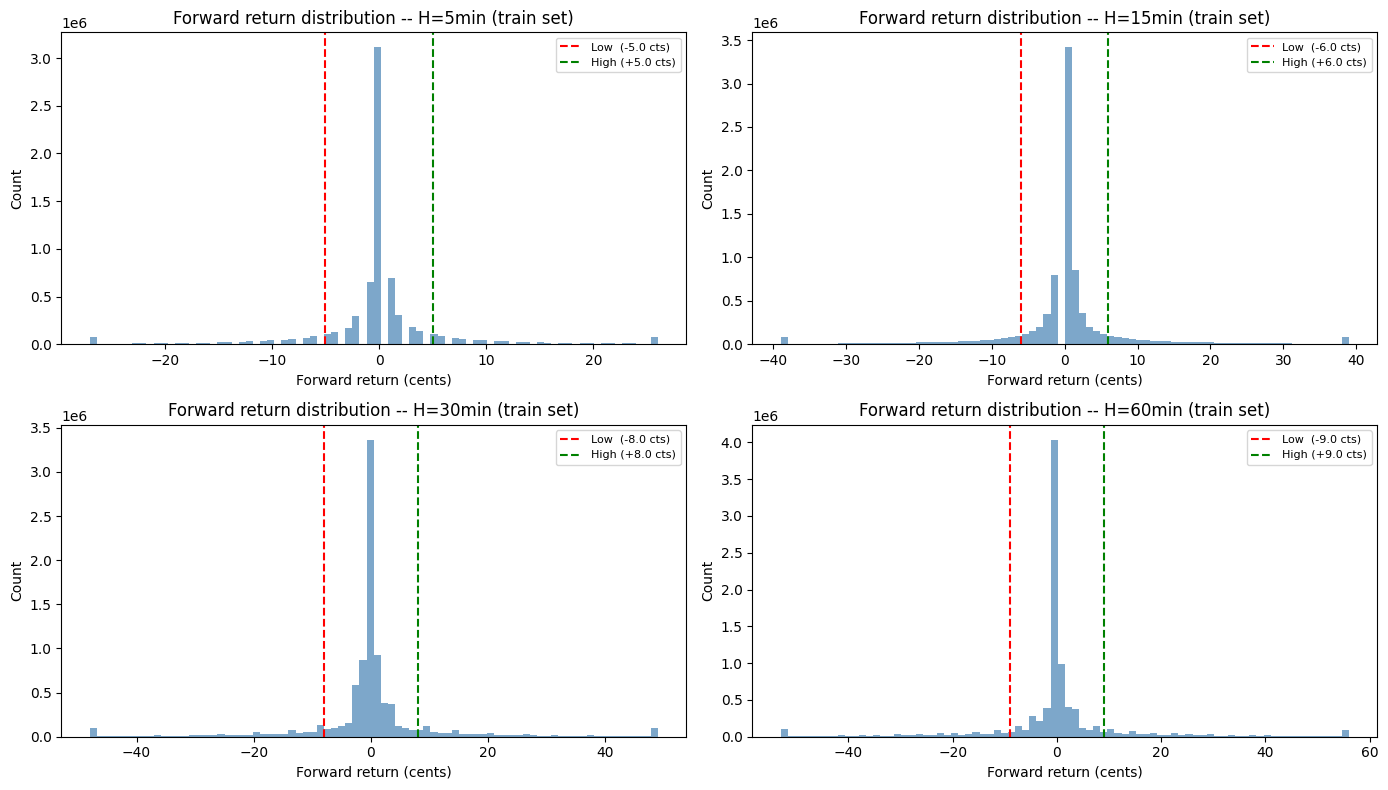

In [14]:
# -- 10. Distribution Plots + Jump Rate Summary --------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

print('=== Jump rate summary ===\n')
print(f'{"Horizon":<10} {"Split":<8} {"Jumps":>10} {"Total":>10} {"Rate":>8}')
print('-' * 50)

for i, H in enumerate(CFG['horizons_min']):
    fwd_col   = f'fwd_ret_{H}m'
    label_col = f'label_{H}m'
    lo, hi    = thresholds[H]

    for split in ['train', 'val', 'test']:
        mask   = bars['split'] == split
        subset = bars.loc[mask, label_col].dropna()
        n_jump = int(subset.sum())
        n_tot  = len(subset)
        rate   = subset.mean()
        print(f'H={H:2d}min     {split:<8} {n_jump:>10,} {n_tot:>10,} {rate:>8.1%}')
    print()

    # Plot
    train_ret = bars.loc[train_mask, fwd_col].dropna()
    clipped   = train_ret.clip(train_ret.quantile(0.01), train_ret.quantile(0.99))

    ax = axes[i]
    ax.hist(clipped, bins=80, alpha=0.7, edgecolor='none', color='steelblue')
    ax.axvline(lo, color='red',   lw=1.5, linestyle='--', label=f'Low  ({lo:+.1f} cts)')
    ax.axvline(hi, color='green', lw=1.5, linestyle='--', label=f'High ({hi:+.1f} cts)')
    ax.set_title(f'Forward return distribution -- H={H}min (train set)')
    ax.set_xlabel('Forward return (cents)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### Step 5 - Save / Load `bars_clean.parquet`

**Checkpoint:** if `bars_clean.parquet` already exists on Drive we load it directly and skip Steps 2-4. If the file is absent we run the full pipeline and save it here. Either way `bars` and all derived variables are ready after this cell.

In [15]:
# -- 11. Save Clean Dataset (skip if already exists) ---------------------------
if os.path.exists(OUTPUT_PATH):
    print(f'File already exists, loading: {OUTPUT_PATH}')
    bars = pd.read_parquet(OUTPUT_PATH)

    FEATURE_COLS = ['close_norm', 'ret_1', 'ret_5', 'log_volume', 'hour_sin', 'hour_cos']
    fwd_cols     = [f'fwd_ret_{H}m' for H in CFG['horizons_min']]
    label_cols   = [f'label_{H}m'   for H in CFG['horizons_min']]
    train_mask   = bars['split'] == 'train'

    thresholds = {}
    for H in CFG['horizons_min']:
        train_ret = bars.loc[train_mask, f'fwd_ret_{H}m'].dropna()
        thresholds[H] = (
            train_ret.quantile(CFG['jump_pct_low']),
            train_ret.quantile(CFG['jump_pct_high']),
        )
    print(f'Ready -- shape: {bars.shape}')

else:
    save_cols = (
        ['ticker', 'ts', 'close', 'volume', 'n_trades']
        + FEATURE_COLS
        + fwd_cols
        + label_cols
        + ['split']
    )
    save_cols = [c for c in save_cols if c in bars.columns]
    bars[save_cols].to_parquet(OUTPUT_PATH, index=False)
    print(f'Saved  : {OUTPUT_PATH}')
    print(f'Shape  : {bars[save_cols].shape}')

File already exists, loading: /content/drive/MyDrive/CS1090B/project/data/kalshi/processed/bars_clean.parquet
Ready -- shape: (16492661, 20)


### Step 6 - Train / Load CNNs

We train one `JumpCNN` per horizon (H ∈ {5, 15, 30, 60} min), or skip training entirely if all four `.pt` checkpoints already exist.

Key design choices vs. the old baseline:
* `BarDataset` enforces a `MAX_WINDOW_MINUTES = 90` cap so a 32-bar window spanning several hours of inactivity is rejected rather than used.
* `BCEWithLogitsLoss` with `pos_weight` handles class imbalance.
* After training we run a precision-threshold search on the **validation set** to find the decision boundary that achieves at least `MIN_PRECISION_TARGET = 0.60` precision.

The architecture is as follows:

**Input:** $(B, F, 32)$ - batch size $B$, $F$ features, lookback of 32 bars.

---

#### Block 1 - extract local patterns, downsample to 16

| Layer | Output shape |
|---|---|
| `Conv1d(F → 64, k=3, p=1)` → BN → ReLU | $(B, 64, 32)$ |
| `Conv1d(64 → 64, k=3, p=1)` → BN → ReLU | $(B, 64, 32)$ |
| `MaxPool1d(2)` → `Dropout(0.2)` | $(B, 64, 16)$ |

$\downarrow$

#### Block 2 - deeper features, downsample to 8

| Layer | Output shape |
|---|---|
| `Conv1d(64 → 128, k=3, p=1)` → BN → ReLU | $(B, 128, 16)$ |
| `Conv1d(128 → 128, k=3, p=1)` → BN → ReLU | $(B, 128, 16)$ |
| `MaxPool1d(2)` → `Dropout(0.2)` | $(B, 128, 8)$ |

$\downarrow$

#### Block 3 - widen channels, collapse time

| Layer | Output shape |
|---|---|
| `Conv1d(128 → 256, k=3, p=1)` → BN → ReLU | $(B, 256, 8)$ |
| `AdaptiveAvgPool1d(1)` | $(B, 256, 1)$ |

$\downarrow$

#### Head (classification)

| Layer | Output shape |
|---|---|
| `Flatten` | $(B, 256)$ |
| `Linear(256 → 64)` → ReLU → `Dropout(0.3)` | $(B, 64)$ |
| `Linear(64 → 1)` → `squeeze(1)` | $(B,)$ |

$\downarrow$

**Output:** logit $(B,)$ &mdash; apply `sigmoid` to get $P(\text{jump})$.

In [16]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, average_precision_score
import matplotlib.pyplot as plt
import numpy as np
import time

# ---- Config ------------------------------------------------------------------
LOOKBACK          = 32
BATCH_SIZE        = 512
EPOCHS            = 10
LR                = 1e-3
DEVICE            = 'cuda' if torch.cuda.is_available() else 'cpu'
MAX_WINDOW_MINUTES = 90   # max real time the 32 input bars can span
print(f'Device: {DEVICE}')
print(f'Max window span: {MAX_WINDOW_MINUTES} minutes real time')

# ---- Dataset -----------------------------------------------------------------
class BarDataset(Dataset):
    def __init__(self, df, feature_cols, label_col, lookback, max_window_minutes):
        self.lookback     = lookback
        self.feature_cols = feature_cols
        self.index        = []
        self.arrays       = []
        self.meta         = []

        max_span = pd.Timedelta(minutes=max_window_minutes)

        for ticker, grp in df.groupby('ticker', sort=False):
            grp = grp.sort_values('ts').reset_index(drop=True)
            X   = grp[feature_cols].values.astype(np.float32)
            y   = grp[label_col].values.astype(np.float32)
            ts  = pd.DatetimeIndex(grp['ts'].values)

            arr_idx = len(self.arrays)
            self.arrays.append((X, y))

            for t in range(lookback, len(grp)):
                if np.isnan(y[t]):
                    continue
                if np.isnan(X[t - lookback : t]).any():
                    continue

                # Check temporal coherence: window must span <= MAX_WINDOW_MINUTES
                window_span = ts[t - 1] - ts[t - lookback]
                if window_span > max_span:
                    continue

                self.index.append((arr_idx, t))
                self.meta.append((ticker, grp['ts'].iloc[t], y[t]))

        self.labels = np.array([
            self.arrays[arr_idx][1][t]
            for arr_idx, t in self.index
        ], dtype=np.float32)

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        arr_idx, t = self.index[idx]
        X, y = self.arrays[arr_idx]
        window = X[t - self.lookback : t].T.copy()
        return torch.from_numpy(window), torch.tensor(y[t])

# ---- Model -------------------------------------------------------------------
class JumpCNN(nn.Module):
    def __init__(self, n_features, lookback):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(n_features, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Conv1d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.2),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.2),
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.head(self.net(x)).squeeze(1)

# ---- Training helpers --------------------------------------------------------
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(X), y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y)
    return total_loss / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_logits, all_labels = [], []
    for X, y in loader:
        logits = model(X.to(DEVICE)).cpu()
        all_logits.append(logits)
        all_labels.append(y)
    logits = torch.cat(all_logits).numpy()
    labels = torch.cat(all_labels).numpy()
    probs  = torch.sigmoid(torch.from_numpy(logits)).numpy()
    loss   = nn.BCEWithLogitsLoss()(torch.from_numpy(logits),
                                    torch.from_numpy(labels)).item()
    return loss, roc_auc_score(labels, probs), average_precision_score(labels, probs), probs, labels

# ---- Checkpoints dir ---------------------------------------------------------
CHECKPOINTS_DIR = os.path.join(PROJECT_DIR, 'checkpoints')
os.makedirs(CHECKPOINTS_DIR, exist_ok=True)

# ---- Check whether all checkpoints already exist (skip training if so) ------
_all_ckpt_paths = {H: os.path.join(CHECKPOINTS_DIR, f'cnn_jump_{H}m.pt')
                   for H in CFG['horizons_min']}
_all_exist = all(os.path.exists(p) for p in _all_ckpt_paths.values())

results = {}

if _all_exist:
    print('All checkpoints found — loading saved models, skipping training.')
    for H in CFG['horizons_min']:
        ckpt_path = _all_ckpt_paths[H]
        _ck = torch.load(ckpt_path,
                         map_location=DEVICE, weights_only=False)
        _m  = JumpCNN(n_features=len(_ck['feature_cols']),
                      lookback=_ck['lookback']).to(DEVICE)
        _m.load_state_dict(_ck['model_state_dict'])
        _m.eval()

        # Check if test_probs and test_labels exist in checkpoint; if not, compute them
        test_probs_loaded = _ck.get('test_probs', None)
        test_labels_loaded = _ck.get('test_labels', None)

        if test_probs_loaded is None or test_labels_loaded is None:
            print(f"  Warning: test_probs/labels not found in checkpoint for H={H}m. Computing them now...")
            # Dynamically create the label_col based on H
            label_col = f'label_{H}m'

            # Need to get test data to compute these
            test_df = bars[bars['split'] == 'test'].copy()
            test_ds = BarDataset(
                test_df, FEATURE_COLS, label_col, LOOKBACK, MAX_WINDOW_MINUTES
            )
            test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

            _, _, _, test_probs_computed, test_labels_computed = evaluate(_m, test_loader)
            test_probs_to_store = test_probs_computed
            test_labels_to_store = test_labels_computed
        else:
            test_probs_to_store = test_probs_loaded
            test_labels_to_store = test_labels_loaded

        results[H] = {
            'model': _m, 'history': _ck.get('history', {}),
            'test_roc': _ck['test_roc'], 'test_pr': _ck['test_pr'],
            'test_probs':  test_probs_to_store,
            'test_labels': test_labels_to_store,
        }
        print(f'  Loaded CNN_{H}m  |  '
              f'AUC-ROC={_ck["test_roc"]:.4f}  '
              f'AUC-PR={_ck["test_pr"]:.4f}')

Device: cuda
Max window span: 90 minutes real time
All checkpoints found — loading saved models, skipping training.
  Loaded CNN_5m  |  AUC-ROC=0.9124  AUC-PR=0.6163
  Loaded CNN_15m  |  AUC-ROC=0.9108  AUC-PR=0.6991
  Loaded CNN_30m  |  AUC-ROC=0.9068  AUC-PR=0.7279
  Loaded CNN_60m  |  AUC-ROC=0.9033  AUC-PR=0.7917


In [17]:
# -- 13. Load Checkpoints for Inference (no retraining) -----------------------
import sys, os, torch, torch.nn as nn, numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_DIR = '/content/drive/MyDrive/CS1090B/project'
else:
    from pathlib import Path
    PROJECT_DIR = str(Path.cwd().resolve())

CHECKPOINTS_DIR = os.path.join(PROJECT_DIR, 'checkpoints')
DEVICE          = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device          : {DEVICE}')
print(f'Checkpoints dir : {CHECKPOINTS_DIR}')


# ---- Inference dataset -------------------------------------------------------
class InferenceDataset(Dataset):
    def __init__(self, df, feature_cols, lookback, max_window_minutes):
        self.lookback     = lookback
        self.feature_cols = feature_cols
        self.index        = []
        self.arrays       = []
        self.meta         = []
        max_span          = pd.Timedelta(minutes=max_window_minutes)

        for ticker, grp in df.groupby('ticker', sort=False):
            grp  = grp.sort_values('ts').reset_index(drop=True)
            X    = grp[feature_cols].values.astype(np.float32)
            ts   = pd.DatetimeIndex(grp['ts'].values)
            arr_idx = len(self.arrays)
            self.arrays.append(X)

            for t in range(lookback, len(grp)):
                if np.isnan(X[t - lookback : t]).any():
                    continue
                if (ts[t - 1] - ts[t - lookback]) > max_span:
                    continue
                self.index.append((arr_idx, t))
                self.meta.append((ticker, grp['ts'].iloc[t]))

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        arr_idx, t = self.index[idx]
        X = self.arrays[arr_idx]
        window = X[t - self.lookback : t].T.copy()
        return torch.from_numpy(window), idx

# ---- Load all checkpoints ----------------------------------------------------
HORIZONS = [5, 15, 30, 60]
CNN_5m = CNN_15m = CNN_30m = CNN_60m = None
loaded_models = {}

for H in HORIZONS:
    ckpt_path = os.path.join(CHECKPOINTS_DIR, f'cnn_jump_{H}m.pt')
    if not os.path.exists(ckpt_path):
        print(f'NOT FOUND : cnn_jump_{H}m.pt')
        continue

    ckpt  = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    model = JumpCNN(
        n_features=len(ckpt['feature_cols']),
        lookback=ckpt['lookback']
    ).to(DEVICE)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()

    entry = {
        'model':               model,
        'feature_cols':        ckpt['feature_cols'],
        'lookback':            ckpt['lookback'],
        'max_window_minutes':  ckpt.get('max_window_minutes', 90),
        'test_roc':            ckpt['test_roc'],
        'test_pr':             ckpt['test_pr'],
        'cfg':                 ckpt['cfg'],
    }
    loaded_models[H] = entry
    if H == 5:  CNN_5m  = entry
    if H == 15: CNN_15m = entry
    if H == 30: CNN_30m = entry
    if H == 60: CNN_60m = entry

    print(f'Loaded CNN_{H}m  |  '
          f'AUC-ROC={ckpt["test_roc"]:.4f}  '
          f'AUC-PR={ckpt["test_pr"]:.4f}')

print(f'\nModels ready: {[f"CNN_{H}m" for H in loaded_models]}')

# ---- Inference function ------------------------------------------------------
@torch.no_grad()
def predict(model_entry, df, batch_size=512):
    ds     = InferenceDataset(
        df,
        model_entry['feature_cols'],
        model_entry['lookback'],
        model_entry['max_window_minutes']
    )
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=2)
    model  = model_entry['model']
    model.eval()

    all_probs = []
    all_idxs  = []
    for X, idxs in loader:
        probs = torch.sigmoid(model(X.to(DEVICE))).cpu().numpy()
        all_probs.extend(probs.tolist())
        all_idxs.extend(idxs.numpy().tolist())

    return pd.DataFrame({
        'ticker':    [ds.meta[i][0] for i in all_idxs],
        'ts':        [ds.meta[i][1] for i in all_idxs],
        'prob_jump': all_probs,
    })

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device          : cuda
Checkpoints dir : /content/drive/MyDrive/CS1090B/project/checkpoints
Loaded CNN_5m  |  AUC-ROC=0.9124  AUC-PR=0.6163
Loaded CNN_15m  |  AUC-ROC=0.9108  AUC-PR=0.6991
Loaded CNN_30m  |  AUC-ROC=0.9068  AUC-PR=0.7279
Loaded CNN_60m  |  AUC-ROC=0.9033  AUC-PR=0.7917

Models ready: ['CNN_5m', 'CNN_15m', 'CNN_30m', 'CNN_60m']


Finding optimal threshold (min precision = 60%) on val set...

H= 5min | optimal threshold=0.781 | val precision=60.0% | val recall=54.3%
H=15min | optimal threshold=0.483 | val precision=60.0% | val recall=86.0%
H=30min | optimal threshold=0.336 | val precision=60.0% | val recall=88.5%
H=60min | optimal threshold=0.199 | val precision=60.0% | val recall=90.5%

=== Test set evaluation with precision-optimized thresholds ===

 horizon_min  threshold  jump_rate  predicted_jump_rate  accuracy  balanced_accuracy  precision   recall       f1      mcc  auc_roc   auc_pr  pct_real_jumps_caught  pct_predicted_jumps_correct  true_jumps_correct  true_jumps_missed  false_alarms
           5   0.781367   0.163265             0.146222  0.867065           0.735719   0.603713 0.540691 0.570466 0.493159 0.912407 0.616319               0.540691                     0.603713               83182              70662         54602
          15   0.483497   0.219172             0.312666  0.841872           0.8

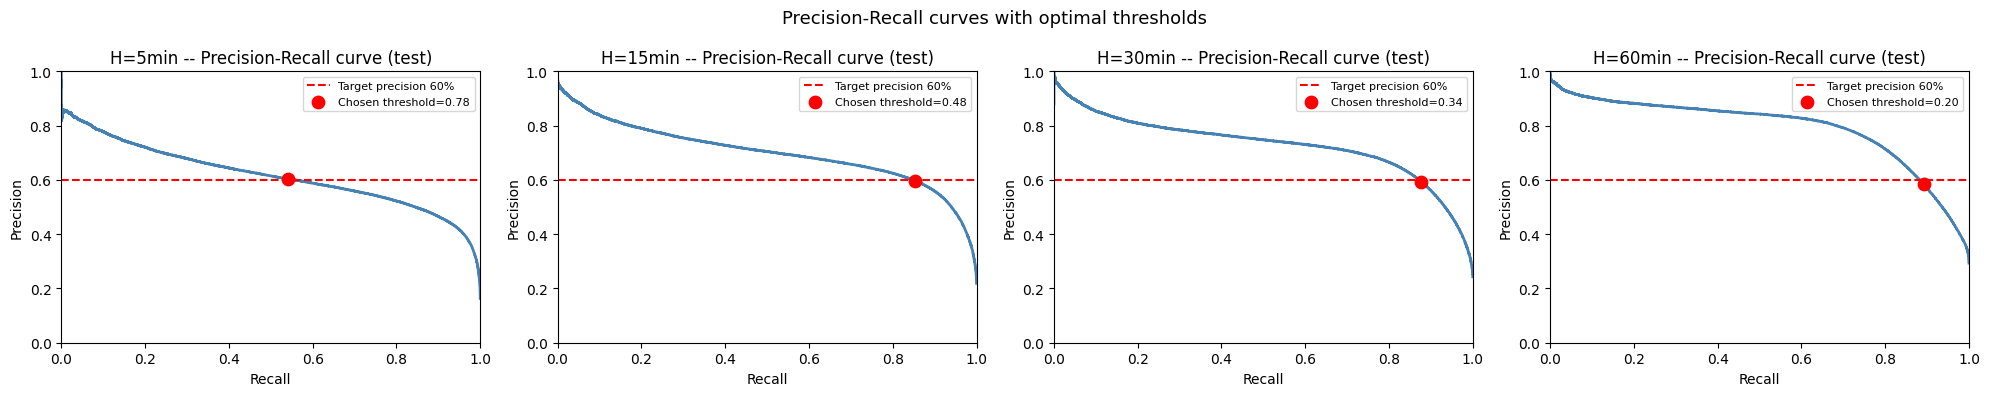

In [18]:
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, matthews_corrcoef, confusion_matrix,
    precision_recall_curve
)
import pandas as pd
import numpy as np

# ---- Target minimum precision ------------------------------------------------
# The model says "jump" only when it exceeds this precision threshold.
# Increase to be more selective (fewer but more reliable signals).
# 0.60 = at least 60% of predicted jumps must be real jumps.
MIN_PRECISION_TARGET = 0.60

# ---- Find optimal threshold on VALIDATION SET --------------------------------
# We search for the lowest threshold that achieves MIN_PRECISION_TARGET.
# Using val set only -- test set is never touched during threshold selection.

def find_threshold_for_precision(labels, probs, min_precision):
    precisions, recalls, thresholds = precision_recall_curve(labels, probs)
    # precision_recall_curve returns one more precision/recall than thresholds
    # thresholds[i] corresponds to precisions[i+1], recalls[i+1]
    valid = np.where(precisions[:-1] >= min_precision)[0]
    if len(valid) == 0:
        print(f'  WARNING: cannot reach precision {min_precision:.0%} -- using 0.5')
        return 0.5, 0.0, 0.0
    # Among valid thresholds, pick the one with highest recall
    best_idx  = valid[np.argmax(recalls[:-1][valid])]
    threshold = thresholds[best_idx]
    precision = precisions[best_idx]
    recall    = recalls[best_idx]
    return threshold, precision, recall

def evaluate_jump_success(labels, probs, threshold):
    preds = (probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, preds).ravel()
    return {
        'threshold':                  threshold,
        'jump_rate':                  labels.mean(),
        'predicted_jump_rate':        preds.mean(),
        'accuracy':                   accuracy_score(labels, preds),
        'balanced_accuracy':          balanced_accuracy_score(labels, preds),
        'precision':                  precision_score(labels, preds, zero_division=0),
        'recall':                     recall_score(labels, preds, zero_division=0),
        'f1':                         f1_score(labels, preds, zero_division=0),
        'mcc':                        matthews_corrcoef(labels, preds),
        'true_jumps_correct':         tp,
        'true_jumps_missed':          fn,
        'false_alarms':               fp,
        'true_no_jumps_correct':      tn,
        'pct_real_jumps_caught':      tp / (tp + fn) if (tp + fn) > 0 else np.nan,
        'pct_predicted_jumps_correct': tp / (tp + fp) if (tp + fp) > 0 else np.nan,
    }

# ---- Build val predictions from loaded models --------------------------------
# We need val set predictions to find the threshold.
# Uses the InferenceDataset from block 13.

print(f'Finding optimal threshold (min precision = {MIN_PRECISION_TARGET:.0%}) on val set...\n')

val_df     = bars[bars['split'] == 'val'].copy()
optimal_thresholds = {}

for H, entry in loaded_models.items():
    label_col = f'label_{H}m'

    # Get val predictions
    val_preds_df = predict(entry, val_df)

    # Match predictions back to labels
    val_labeled = val_df[['ticker', 'ts', label_col]].dropna(subset=[label_col])
    val_merged  = val_preds_df.merge(
        val_labeled,
        on=['ticker', 'ts'],
        how='inner'
    )

    if len(val_merged) == 0:
        print(f'H={H}min: no val predictions found, using threshold=0.5')
        optimal_thresholds[H] = 0.5
        continue

    val_labels = val_merged[label_col].values.astype(int)
    val_probs  = val_merged['prob_jump'].values

    threshold, precision, recall = find_threshold_for_precision(
        val_labels, val_probs, MIN_PRECISION_TARGET
    )
    optimal_thresholds[H] = threshold

    print(f'H={H:2d}min | optimal threshold={threshold:.3f} | '
          f'val precision={precision:.1%} | val recall={recall:.1%}')

# ---- Evaluate on TEST SET with optimal thresholds ---------------------------
print(f'\n=== Test set evaluation with precision-optimized thresholds ===\n')

rows = []

for H, res in results.items():
    labels    = res['test_labels'].astype(int)
    probs     = res['test_probs']
    threshold = optimal_thresholds[H]

    metrics               = evaluate_jump_success(labels, probs, threshold)
    metrics['horizon_min'] = H
    metrics['auc_roc']    = res['test_roc']
    metrics['auc_pr']     = res['test_pr']
    rows.append(metrics)

test_summary = pd.DataFrame(rows).sort_values('horizon_min')

cols = [
    'horizon_min', 'threshold', 'jump_rate', 'predicted_jump_rate',
    'accuracy', 'balanced_accuracy', 'precision', 'recall', 'f1', 'mcc',
    'auc_roc', 'auc_pr',
    'pct_real_jumps_caught', 'pct_predicted_jumps_correct',
    'true_jumps_correct', 'true_jumps_missed', 'false_alarms',
]
print(test_summary[cols].to_string(index=False))

# ---- Precision-Recall curve plot --------------------------------------------
fig, axes = plt.subplots(1, len(loaded_models), figsize=(5 * len(loaded_models), 4))
if len(loaded_models) == 1:
    axes = [axes]

for ax, (H, res) in zip(axes, results.items()):
    labels = res['test_labels'].astype(int)
    probs  = res['test_probs']
    prec, rec, thresh = precision_recall_curve(labels, probs)

    ax.plot(rec, prec, color='steelblue', lw=2)
    ax.axhline(MIN_PRECISION_TARGET, color='red', lw=1.5, linestyle='--',
               label=f'Target precision {MIN_PRECISION_TARGET:.0%}')

    # Mark the chosen threshold
    opt_thresh = optimal_thresholds[H]
    opt_preds  = (probs >= opt_thresh).astype(int)
    opt_prec   = precision_score(labels, opt_preds, zero_division=0)
    opt_rec    = recall_score(labels, opt_preds, zero_division=0)
    ax.scatter([opt_rec], [opt_prec], color='red', s=80, zorder=5,
               label=f'Chosen threshold={opt_thresh:.2f}')

    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(f'H={H}min -- Precision-Recall curve (test)')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)

plt.suptitle('Precision-Recall curves with optimal thresholds', fontsize=13)
plt.tight_layout()
plt.show()

### Step 7 - Prediction Analysis

We inspect the close price distribution to understand where jumps cluster, then visualise the 32-bar input window together with the actual future price for the model's most confident predictions. The flat-price pattern flagged below points to a known issue with illiquid markets.

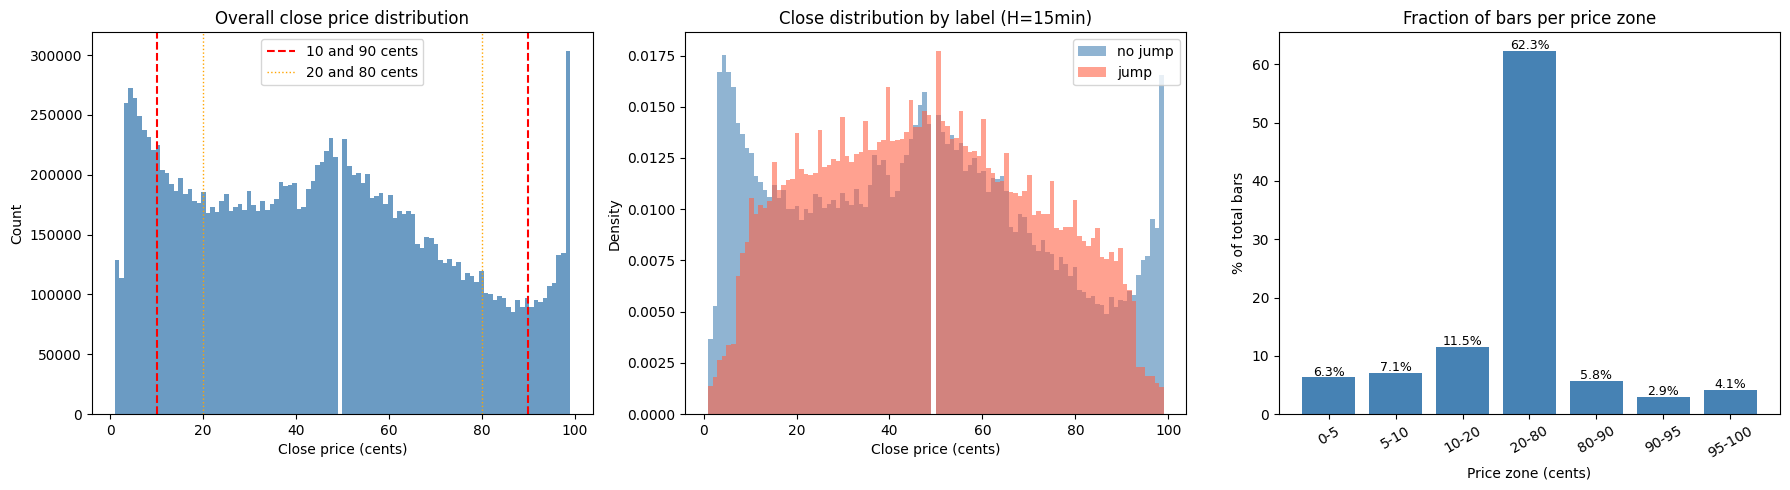

=== Close price summary ===

Mean   : 44.6 cents
Median : 44.0 cents
Std    : 27.6 cents

Bars with close <= 10  : 13.4%
Bars with close >= 90  : 7.7%
Bars with close in [20,80] : 63.5%

=== Jump rate (label_15m) by price zone ===

Zone            Jump rate     N bars
------------------------------------
0-10 cents           7.9%  1,225,731
10-20 cents          20.3%  1,334,055
20-80 cents          22.9%  8,235,119
80-90 cents          27.6%    763,325
90-100 cents          10.7%    868,433


In [19]:
# -- 14. Close Price Distribution Analysis ------------------------------------
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Overall close distribution
ax = axes[0]
ax.hist(bars['close'].dropna(), bins=100, edgecolor='none', alpha=0.8, color='steelblue')
ax.set_title('Overall close price distribution')
ax.set_xlabel('Close price (cents)')
ax.set_ylabel('Count')
ax.axvline(10,  color='red',    lw=1.5, linestyle='--', label='10 and 90 cents')
ax.axvline(90,  color='red',    lw=1.5, linestyle='--')
ax.axvline(20,  color='orange', lw=1,   linestyle=':',  label='20 and 80 cents')
ax.axvline(80,  color='orange', lw=1,   linestyle=':')
ax.legend()

# 2. Close distribution split by label (using H=15min as reference)
ax = axes[1]
label_col = 'label_15m'
jump_mask   = bars[label_col] == 1
nojump_mask = bars[label_col] == 0
ax.hist(bars.loc[nojump_mask, 'close'].dropna(), bins=100, alpha=0.6,
        color='steelblue', density=True, label='no jump')
ax.hist(bars.loc[jump_mask,   'close'].dropna(), bins=100, alpha=0.6,
        color='tomato',    density=True, label='jump')
ax.set_title('Close distribution by label (H=15min)')
ax.set_xlabel('Close price (cents)')
ax.set_ylabel('Density')
ax.legend()

# 3. Fraction of bars in extreme zones
zones = {
    '0-5':   (bars['close'] <= 5).mean(),
    '5-10':  ((bars['close'] > 5)  & (bars['close'] <= 10)).mean(),
    '10-20': ((bars['close'] > 10) & (bars['close'] <= 20)).mean(),
    '20-80': ((bars['close'] > 20) & (bars['close'] <= 80)).mean(),
    '80-90': ((bars['close'] > 80) & (bars['close'] <= 90)).mean(),
    '90-95': ((bars['close'] > 90) & (bars['close'] <= 95)).mean(),
    '95-100':( bars['close'] > 95).mean(),
}
ax = axes[2]
ax.bar(zones.keys(), [v * 100 for v in zones.values()], color='steelblue', edgecolor='none')
ax.set_title('Fraction of bars per price zone')
ax.set_xlabel('Price zone (cents)')
ax.set_ylabel('% of total bars')
ax.tick_params(axis='x', rotation=30)
for i, (k, v) in enumerate(zones.items()):
    ax.text(i, v * 100 + 0.3, f'{v:.1%}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Numeric summary
print('=== Close price summary ===\n')
print(f'Mean   : {bars["close"].mean():.1f} cents')
print(f'Median : {bars["close"].median():.1f} cents')
print(f'Std    : {bars["close"].std():.1f} cents')
print()
print(f'Bars with close <= 10  : {(bars["close"] <= 10).mean():.1%}')
print(f'Bars with close >= 90  : {(bars["close"] >= 90).mean():.1%}')
print(f'Bars with close in [20,80] : {((bars["close"] >= 20) & (bars["close"] <= 80)).mean():.1%}')
print()

# Jump rate by price zone
print('=== Jump rate (label_15m) by price zone ===\n')
print(f'{"Zone":<12} {"Jump rate":>12} {"N bars":>10}')
print('-' * 36)
zone_bounds = [(0, 10), (10, 20), (20, 80), (80, 90), (90, 100)]
for lo, hi in zone_bounds:
    mask  = (bars['close'] >= lo) & (bars['close'] < hi)
    sub   = bars.loc[mask, 'label_15m'].dropna()
    rate  = sub.mean()
    n     = len(sub)
    print(f'{lo}-{hi} cents   {rate:>12.1%} {n:>10,}')

Top 10 most confident JUMP predictions (H=15min):


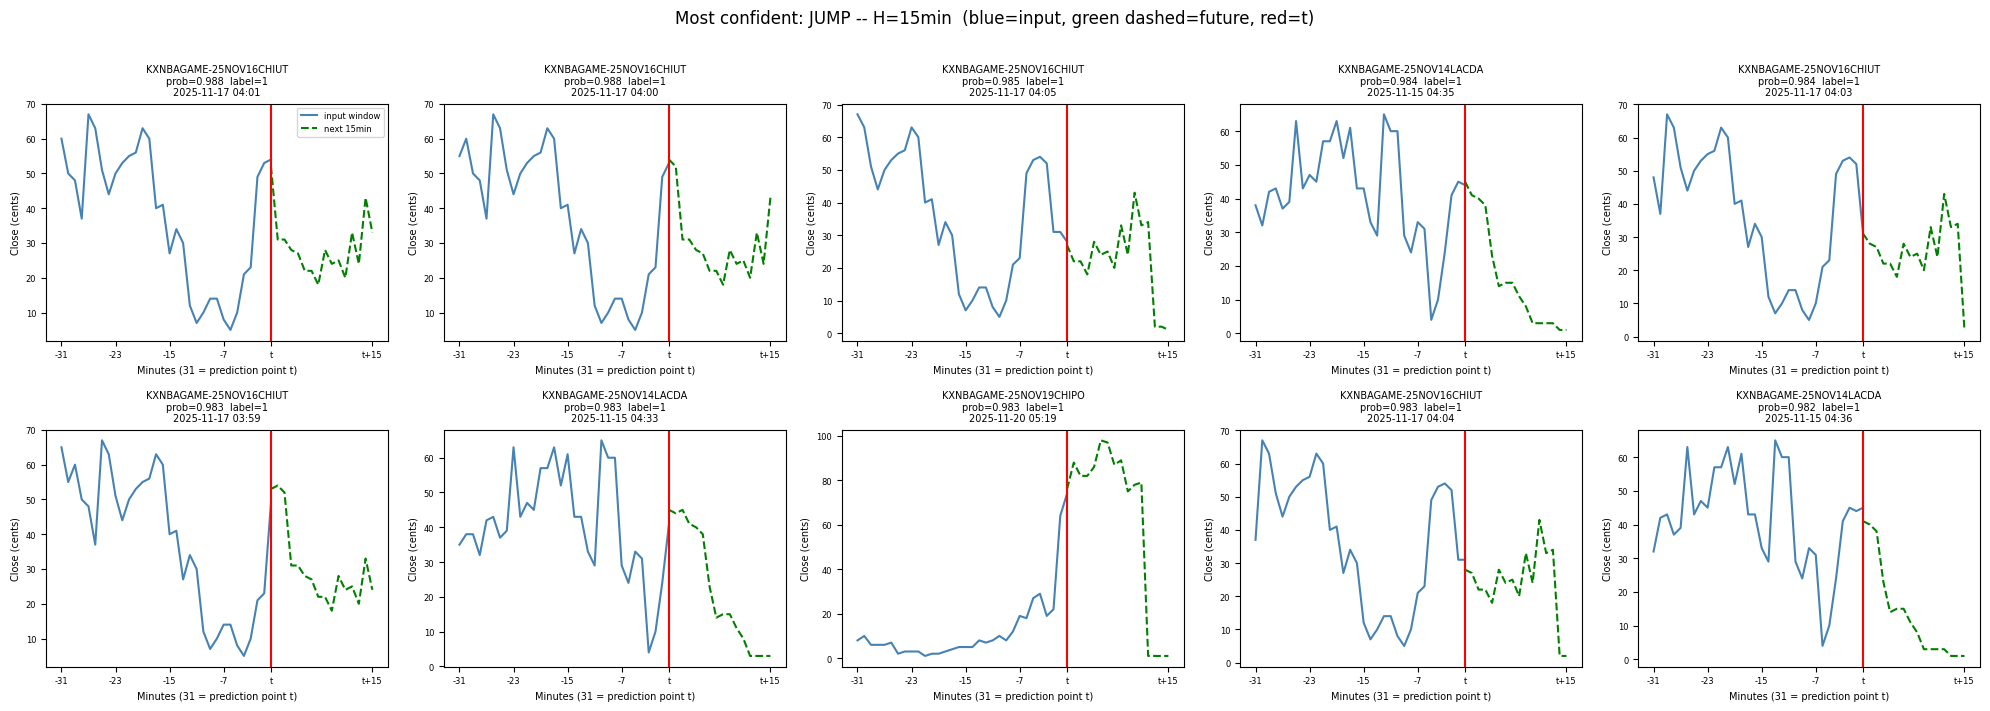

Top 10 most confident NO-JUMP predictions (H=15min):


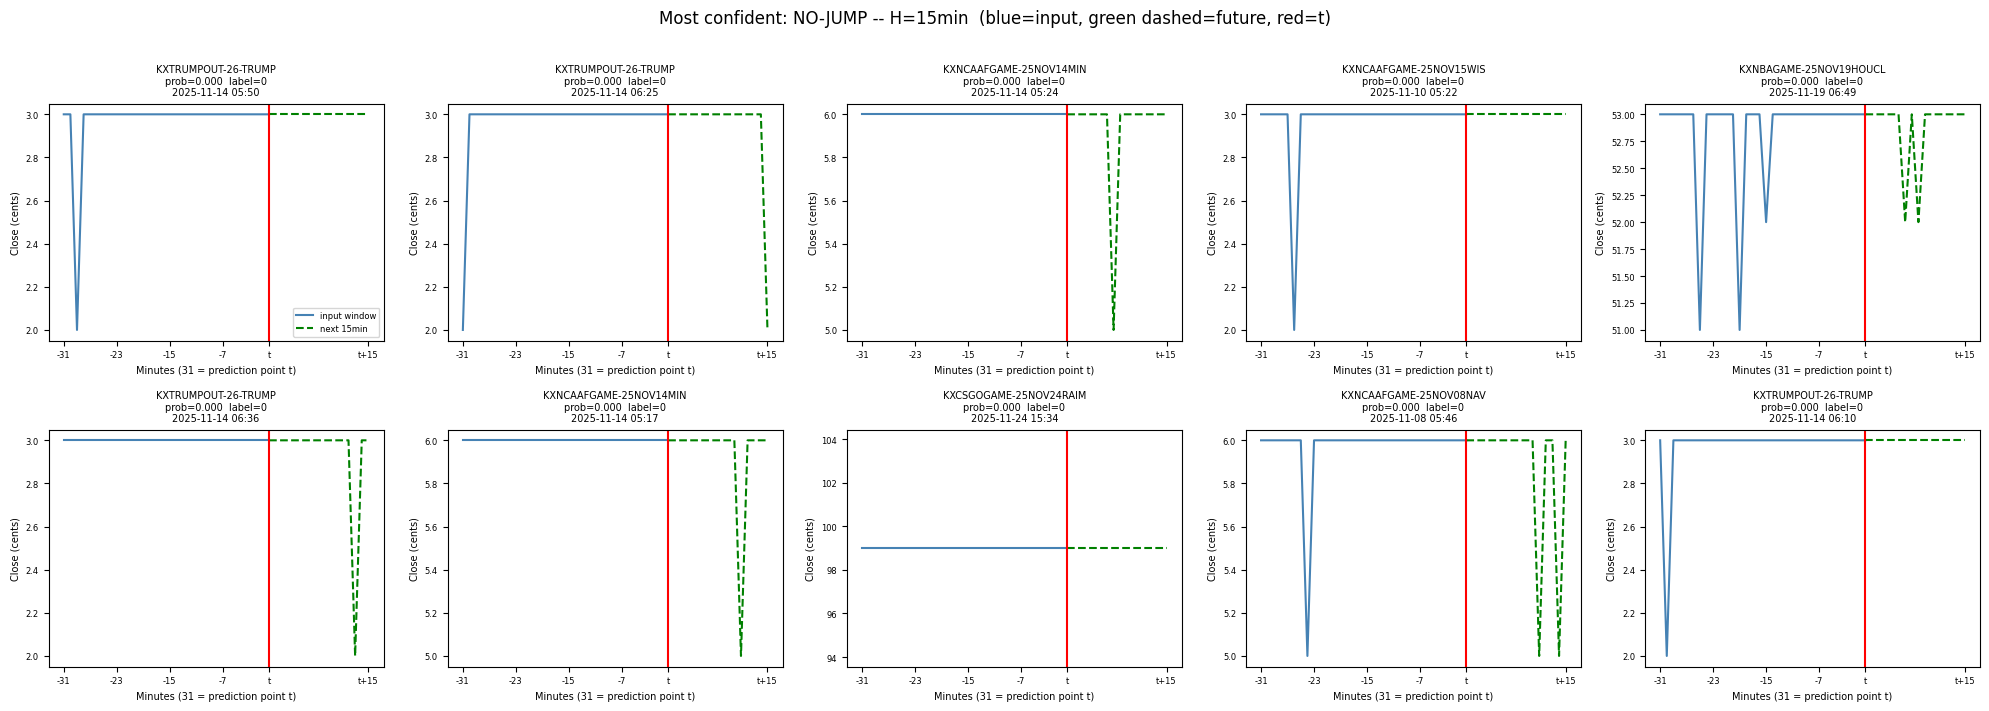

In [20]:
# -- 16. Most confident predictions: time series with future realization -------
# Shows the 32-bar input window + H bars of actual future price after t.
# Red vertical line = prediction point t.
# Blue solid = input window (what the model saw).
# Green dashed = actual future price (what happened after t).

import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

N_EXAMPLES   = 10
H            = 15
label_col    = f'label_{H}m'
model_entry  = CNN_15m
FEATURE_COLS = model_entry['feature_cols']
LOOKBACK     = model_entry['lookback']
model        = model_entry['model']
model.eval()

# ---- Dataset that also stores future close prices ----------------------------
class WindowDatasetWithFuture(Dataset):
    def __init__(self, df, feature_cols, label_col, lookback, horizon):
        self.lookback     = lookback
        self.horizon      = horizon
        self.feature_cols = feature_cols
        self.index        = []
        self.arrays       = []
        self.meta         = []

        for ticker, grp in df.groupby('ticker', sort=False):
            grp = grp.sort_values('ts').reset_index(drop=True)
            X     = grp[feature_cols].values.astype(np.float32)
            y     = grp[label_col].values.astype(np.float32)
            close = grp['close'].values.astype(np.float32)

            arr_idx = len(self.arrays)
            self.arrays.append((X, y, close))

            # Need at least lookback bars before t and horizon bars after t
            for t in range(lookback, len(grp) - horizon):
                if np.isnan(y[t]):
                    continue
                if np.isnan(X[t - lookback : t]).any():
                    continue
                self.index.append((arr_idx, t))
                self.meta.append((ticker, grp['ts'].iloc[t], y[t]))

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        arr_idx, t = self.index[idx]
        X, y, close = self.arrays[arr_idx]
        window = X[t - self.lookback : t].T.copy()
        return torch.from_numpy(window), idx

    def get_close_window(self, idx):
        arr_idx, t = self.index[idx]
        _, _, close = self.arrays[arr_idx]
        return close[t - self.lookback : t]

    def get_future_close(self, idx):
        arr_idx, t = self.index[idx]
        _, _, close = self.arrays[arr_idx]
        # Include t itself as the junction point, then H bars forward
        return close[t : t + self.horizon + 1]

# ---- Build dataset and run inference ----------------------------------------
test_df = bars[bars['split'] == 'test'].copy()
ds      = WindowDatasetWithFuture(test_df, FEATURE_COLS, label_col, LOOKBACK, H)
loader  = DataLoader(ds, batch_size=512, shuffle=False, num_workers=2)

all_probs = []
all_idxs  = []

with torch.no_grad():
    for X, idxs in loader:
        logits = model(X.to(DEVICE)).cpu()
        probs  = torch.sigmoid(logits).numpy()
        all_probs.extend(probs.tolist())
        all_idxs.extend(idxs.numpy().tolist())

all_probs   = np.array(all_probs)
all_idxs    = np.array(all_idxs)
true_labels = np.array([ds.meta[i][2] for i in all_idxs])

# ---- Select top N confident correct predictions ------------------------------
jump_probs              = all_probs.copy()
jump_probs[true_labels != 1] = -1
top_jump_idxs           = all_idxs[np.argsort(jump_probs)[::-1][:N_EXAMPLES]]

nojump_probs            = (1 - all_probs).copy()
nojump_probs[true_labels != 0] = -1
top_nojump_idxs         = all_idxs[np.argsort(nojump_probs)[::-1][:N_EXAMPLES]]

# ---- Plot function -----------------------------------------------------------
def plot_examples_with_future(sample_idxs, title, n_cols=5):
    n_rows = len(sample_idxs) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3.5))
    axes = axes.flatten()

    for plot_i, sample_idx in enumerate(sample_idxs):
        past_close   = ds.get_close_window(sample_idx)   # (LOOKBACK,)
        future_close = ds.get_future_close(sample_idx)   # (H+1,)  starts at t

        ticker, ts, label = ds.meta[sample_idx]
        prob = all_probs[np.where(all_idxs == sample_idx)[0][0]]

        ax = axes[plot_i]

        # X axes: past = [0 .. LOOKBACK-1], future = [LOOKBACK-1 .. LOOKBACK-1+H]
        past_x   = np.arange(LOOKBACK)
        future_x = np.arange(LOOKBACK - 1, LOOKBACK - 1 + len(future_close))

        # Past window -- solid blue
        ax.plot(past_x, past_close, color='steelblue', lw=1.5, label='input window')

        # Future realization -- dashed green
        ax.plot(future_x, future_close, color='green', lw=1.5,
                linestyle='--', label=f'next {H}min')

        # Vertical line at prediction point
        ax.axvline(LOOKBACK - 1, color='red', lw=1.5, linestyle='-')

        ax.set_title(
            f'{ticker[:22]}\n'
            f'prob={prob:.3f}  label={int(label)}\n'
            f'{str(ts)[:16]}',
            fontsize=7
        )
        ax.set_xlabel('Minutes (31 = prediction point t)', fontsize=7)
        ax.set_ylabel('Close (cents)', fontsize=7)
        ax.tick_params(labelsize=6)
        ax.set_xticks([0, 8, 16, 24, LOOKBACK - 1, LOOKBACK - 1 + H])
        ax.set_xticklabels(['-31', '-23', '-15', '-7', 't', f't+{H}'], fontsize=6)

        if plot_i == 0:
            ax.legend(fontsize=6)

    plt.suptitle(title, fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()

# ---- Plot -------------------------------------------------------------------
print(f'Top {N_EXAMPLES} most confident JUMP predictions (H={H}min):')
plot_examples_with_future(
    top_jump_idxs,
    f'Most confident: JUMP -- H={H}min  (blue=input, green dashed=future, red=t)'
)

print(f'Top {N_EXAMPLES} most confident NO-JUMP predictions (H={H}min):')
plot_examples_with_future(
    top_nojump_idxs,
    f'Most confident: NO-JUMP -- H={H}min  (blue=input, green dashed=future, red=t)'
)

**Observation on flat-price illiquid markets.** We notice that many high-confidence predictions come from markets where the price is flat for 1-2 hours and then moves by a single tick.

This is normal for illiquid Kalshi contracts but it inflates AUC. The CNN is simply learning that any tick after a long quiet spell is "a jump". We need to filter or discount these inactive windows in the next milestone.

### Step 8 - Interpretability

We compute input-gradient saliency maps averaged over the 200 most confident jump and no-jump predictions, then run a feature ablation study (zeroing one feature at a time) to measure how much each feature actually drives the output.

Computing gradients for top 200 JUMP examples...
Computing gradients for top 200 NO-JUMP examples...


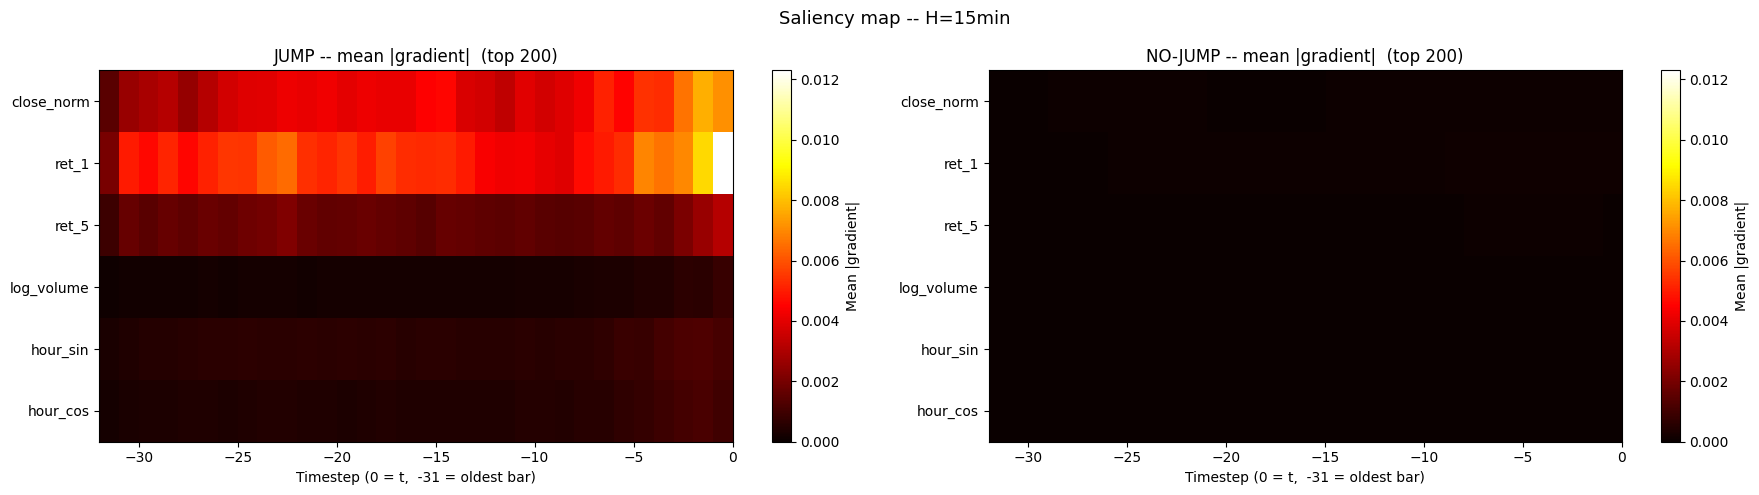

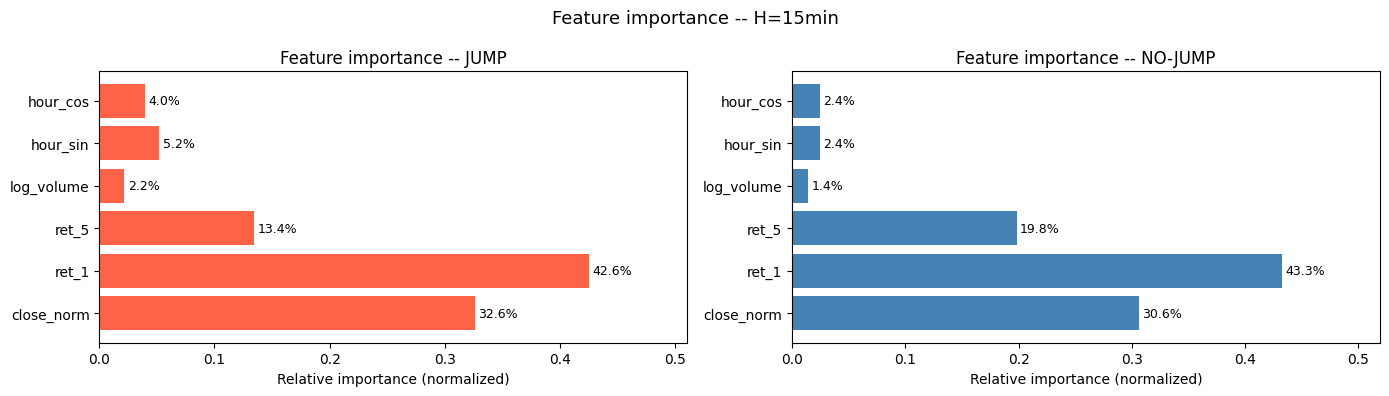

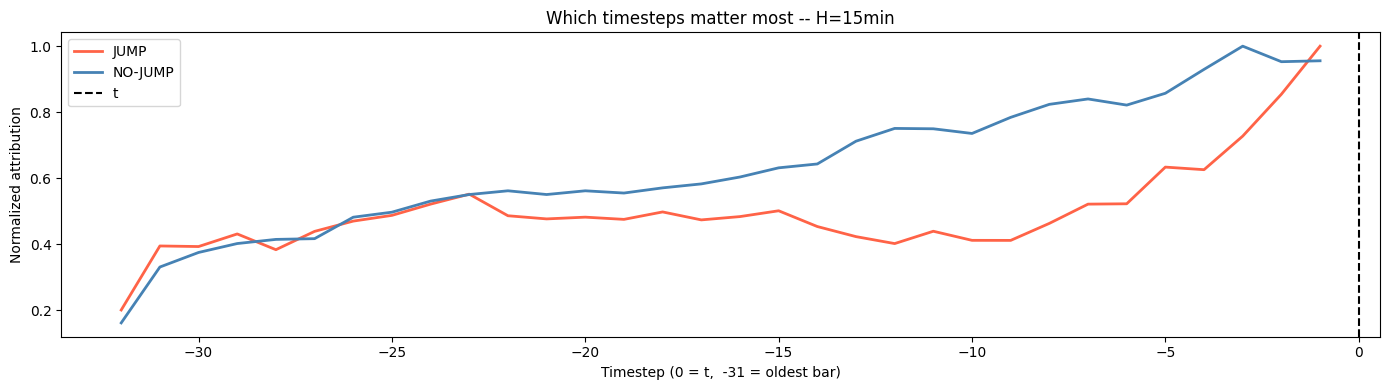

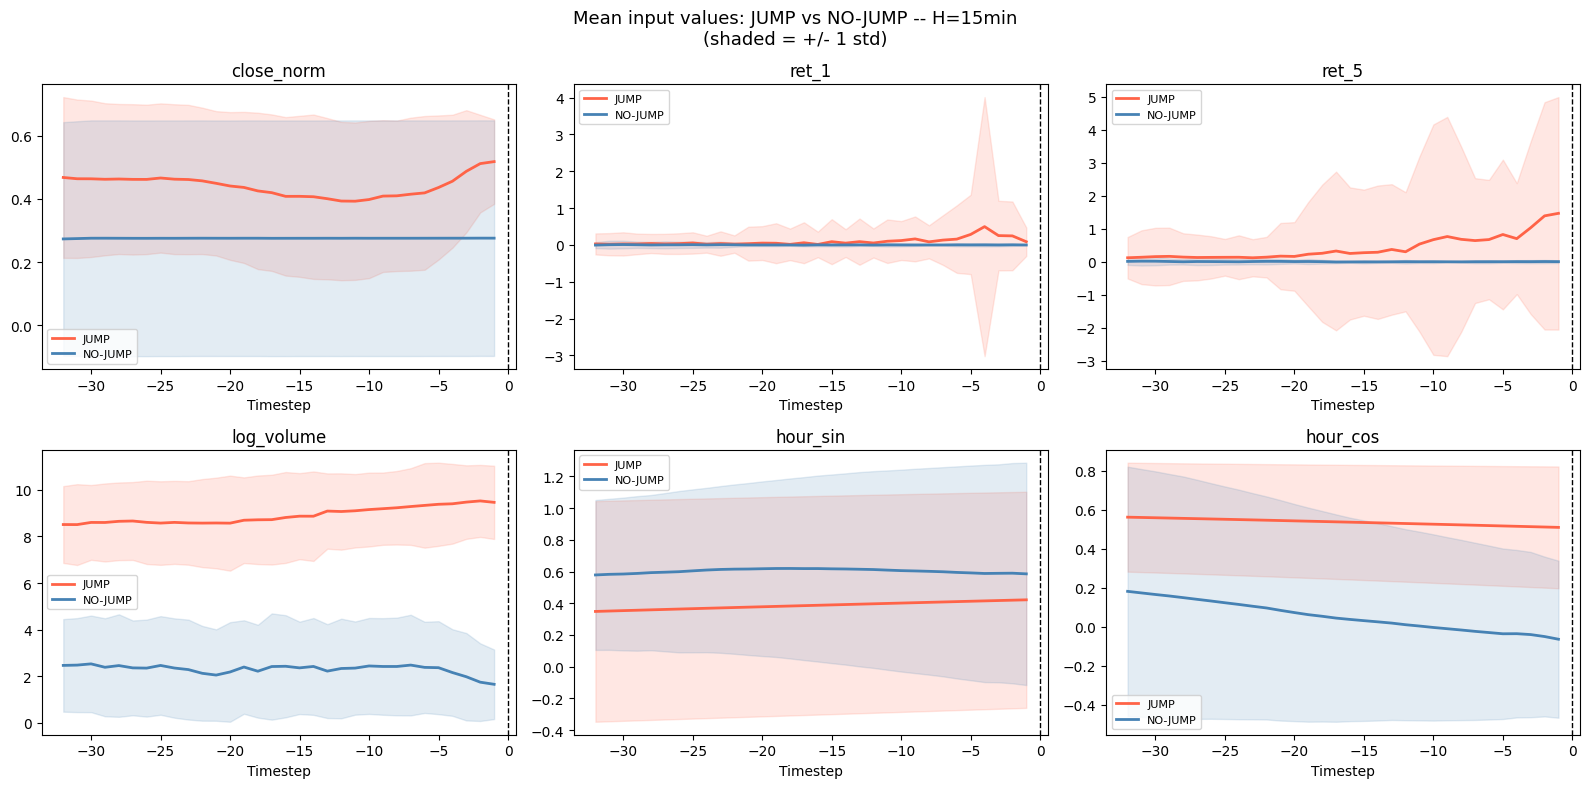


=== Feature importance summary ===

Feature               JUMP    NO-JUMP   Difference
--------------------------------------------------
close_norm           32.6%      30.6%        +2.0%
ret_1                42.6%      43.3%        -0.7%
ret_5                13.4%      19.8%        -6.4%
log_volume            2.2%       1.4%        +0.7%
hour_sin              5.2%       2.4%        +2.8%
hour_cos              4.0%       2.4%        +1.6%

=== Most important timestep ===
JUMP    : t-1  (0 = most recent)
NO-JUMP : t-3  (0 = most recent)

=== Ablation on top 200 JUMP examples ===

Feature zeroed    Mean prob full  Mean prob ablated    Mean drop  >0.1 drop  >0.3 drop
-------------------------------------------------------------------------------------
ret_1                      0.973              0.932        0.041       1.0%       0.0%
ret_5                      0.973              0.933        0.040       4.0%       0.0%
close_norm                 0.973              0.273        0.700 

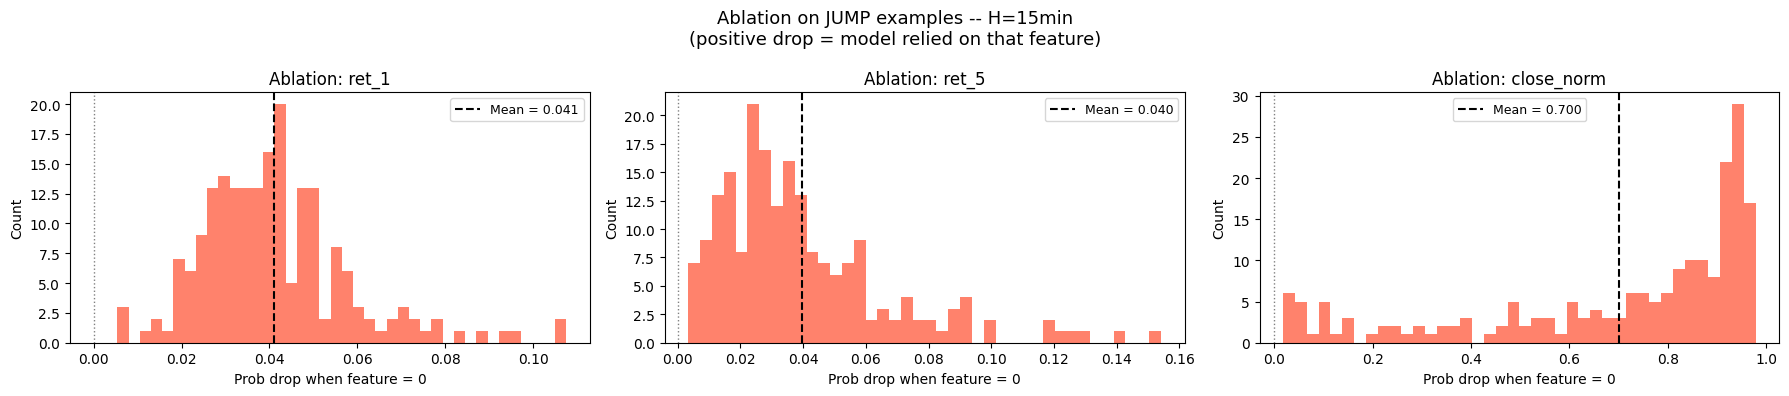

In [21]:
# -- 17. Gradient-based Saliency Maps + Ablation on JUMP examples -------------
import torch
import numpy as np
import matplotlib.pyplot as plt

N_EXAMPLES   = 200
H            = 15
label_col    = f'label_{H}m'
model_entry  = CNN_15m
FEATURE_COLS = model_entry['feature_cols']
LOOKBACK     = model_entry['lookback']
model        = model_entry['model']
model.eval()

# ---- Reuse dataset and predictions from block 16 ----------------------------
# If you have not run block 16, uncomment and run this:
# test_df    = bars[bars['split'] == 'test'].copy()
# ds         = WindowDatasetWithFuture(test_df, FEATURE_COLS, label_col, LOOKBACK, H)
# loader     = torch.utils.data.DataLoader(ds, batch_size=512, shuffle=False, num_workers=2)
# all_probs  = []
# all_idxs   = []
# with torch.no_grad():
#     for X, idxs in loader:
#         logits = model(X.to(DEVICE)).cpu()
#         probs  = torch.sigmoid(logits).numpy()
#         all_probs.extend(probs.tolist())
#         all_idxs.extend(idxs.numpy().tolist())
# all_probs   = np.array(all_probs)
# all_idxs    = np.array(all_idxs)
# true_labels = np.array([ds.meta[i][2] for i in all_idxs])

# ---- Select top-N confident CORRECT predictions ------------------------------
jump_probs              = all_probs.copy()
jump_probs[true_labels != 1] = -1
top_jump_idxs           = all_idxs[np.argsort(jump_probs)[::-1][:N_EXAMPLES]]

nojump_probs            = (1 - all_probs).copy()
nojump_probs[true_labels != 0] = -1
top_nojump_idxs         = all_idxs[np.argsort(nojump_probs)[::-1][:N_EXAMPLES]]

# ---- Gradient computation ----------------------------------------------------
def compute_input_gradients(ds, sample_idxs, model, device):
    grads_list  = []
    inputs_list = []
    model.eval()

    for idx in sample_idxs:
        arr_idx, t = ds.index[idx]
        X_np = ds.arrays[arr_idx][0]   # always take first element regardless of tuple size
        window = X_np[t - ds.lookback : t].T.copy()

        X_tensor = torch.from_numpy(window).unsqueeze(0).to(device)
        X_tensor.requires_grad_(True)

        logit = model(X_tensor)
        prob  = torch.sigmoid(logit)
        prob.backward()

        grad = X_tensor.grad.detach().cpu().numpy()[0]
        grads_list.append(np.abs(grad))
        inputs_list.append(window)

    return np.stack(grads_list), np.stack(inputs_list)


print(f'Computing gradients for top {N_EXAMPLES} JUMP examples...')
grads_jump,   inputs_jump   = compute_input_gradients(ds, top_jump_idxs,   model, DEVICE)

print(f'Computing gradients for top {N_EXAMPLES} NO-JUMP examples...')
grads_nojump, inputs_nojump = compute_input_gradients(ds, top_nojump_idxs, model, DEVICE)

attr_jump   = grads_jump.mean(axis=0)
attr_nojump = grads_nojump.mean(axis=0)

# ---- Plot 1: Heatmap --------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
vmax = max(attr_jump.max(), attr_nojump.max())
timesteps = np.arange(-LOOKBACK, 0)

for ax, attr, title in zip(
    axes,
    [attr_jump, attr_nojump],
    [f'JUMP -- mean |gradient|  (top {N_EXAMPLES})',
     f'NO-JUMP -- mean |gradient|  (top {N_EXAMPLES})']
):
    im = ax.imshow(attr, aspect='auto', cmap='hot', vmin=0, vmax=vmax,
                   extent=[-LOOKBACK, 0, len(FEATURE_COLS) - 0.5, -0.5])
    ax.set_yticks(range(len(FEATURE_COLS)))
    ax.set_yticklabels(FEATURE_COLS, fontsize=10)
    ax.set_xlabel('Timestep (0 = t,  -31 = oldest bar)')
    ax.set_title(title)
    plt.colorbar(im, ax=ax, label='Mean |gradient|')

plt.suptitle(f'Saliency map -- H={H}min', fontsize=13)
plt.tight_layout()
plt.show()

# ---- Plot 2: Feature importance ---------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, attr, title, color in zip(
    axes,
    [attr_jump, attr_nojump],
    ['Feature importance -- JUMP', 'Feature importance -- NO-JUMP'],
    ['tomato', 'steelblue']
):
    importance = attr.sum(axis=1)
    importance = importance / importance.sum()
    ax.barh(FEATURE_COLS, importance, color=color, edgecolor='none')
    ax.set_xlabel('Relative importance (normalized)')
    ax.set_title(title)
    for i, v in enumerate(importance):
        ax.text(v + 0.003, i, f'{v:.1%}', va='center', fontsize=9)
    ax.set_xlim(0, importance.max() * 1.2)

plt.suptitle(f'Feature importance -- H={H}min', fontsize=13)
plt.tight_layout()
plt.show()

# ---- Plot 3: Temporal importance --------------------------------------------
fig, ax = plt.subplots(figsize=(14, 4))

temp_jump   = attr_jump.sum(axis=0)   / attr_jump.sum(axis=0).max()
temp_nojump = attr_nojump.sum(axis=0) / attr_nojump.sum(axis=0).max()

ax.plot(timesteps, temp_jump,   color='tomato',    lw=2, label='JUMP')
ax.plot(timesteps, temp_nojump, color='steelblue', lw=2, label='NO-JUMP')
ax.axvline(0, color='black', lw=1.5, linestyle='--', label='t')
ax.set_xlabel('Timestep (0 = t,  -31 = oldest bar)')
ax.set_ylabel('Normalized attribution')
ax.set_title(f'Which timesteps matter most -- H={H}min')
ax.legend()
plt.tight_layout()
plt.show()

# ---- Plot 4: Mean input values ----------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(FEATURE_COLS):
    ax = axes[i]
    for inp, label, color in zip(
        [inputs_jump, inputs_nojump],
        ['JUMP', 'NO-JUMP'],
        ['tomato', 'steelblue']
    ):
        mean = inp[:, i, :].mean(axis=0)
        std  = inp[:, i, :].std(axis=0)
        ax.plot(timesteps, mean, color=color, lw=2, label=label)
        ax.fill_between(timesteps, mean - std, mean + std, color=color, alpha=0.15)
    ax.axvline(0, color='black', lw=1, linestyle='--')
    ax.set_title(feat)
    ax.set_xlabel('Timestep')
    ax.legend(fontsize=8)

plt.suptitle(f'Mean input values: JUMP vs NO-JUMP -- H={H}min\n(shaded = +/- 1 std)', fontsize=13)
plt.tight_layout()
plt.show()

# ---- Numeric summary --------------------------------------------------------
print('\n=== Feature importance summary ===\n')
print(f'{"Feature":<15} {"JUMP":>10} {"NO-JUMP":>10} {"Difference":>12}')
print('-' * 50)
imp_jump   = attr_jump.sum(axis=1)   / attr_jump.sum()
imp_nojump = attr_nojump.sum(axis=1) / attr_nojump.sum()
for feat, ij, in_ in zip(FEATURE_COLS, imp_jump, imp_nojump):
    print(f'{feat:<15} {ij:>10.1%} {in_:>10.1%} {ij - in_:>+12.1%}')

print(f'\n=== Most important timestep ===')
print(f'JUMP    : t{attr_jump.sum(axis=0).argmax() - LOOKBACK}  (0 = most recent)')
print(f'NO-JUMP : t{attr_nojump.sum(axis=0).argmax() - LOOKBACK}  (0 = most recent)')

# ---- Ablation: ret_1, ret_5, close_norm on JUMP examples --------------------
ABLATION_FEATURES = ['ret_1', 'ret_5', 'close_norm']

print(f'\n=== Ablation on top {N_EXAMPLES} JUMP examples ===\n')
print(f'{"Feature zeroed":<15} {"Mean prob full":>16} {"Mean prob ablated":>18} '
      f'{"Mean drop":>12} {">0.1 drop":>10} {">0.3 drop":>10}')
print('-' * 85)

ablation_results = {}

with torch.no_grad():
    full_probs_list = []
    for idx in top_jump_idxs:
        arr_idx, t = ds.index[idx]
        X_np = ds.arrays[arr_idx][0]
        window = X_np[t - ds.lookback : t].T.copy()
        X_full = torch.from_numpy(window).unsqueeze(0).to(DEVICE)
        p_full = torch.sigmoid(model(X_full)).item()
        full_probs_list.append(p_full)
    full_probs_arr = np.array(full_probs_list)

    for feat_name in ABLATION_FEATURES:
        feat_idx = FEATURE_COLS.index(feat_name)
        ablated_probs_list = []

        for idx in top_jump_idxs:
            arr_idx, t = ds.index[idx]
            X_np = ds.arrays[arr_idx][0]
            window = X_np[t - ds.lookback : t].T.copy()
            window_abl = window.copy()
            window_abl[feat_idx, :] = 0.0
            X_abl = torch.from_numpy(window_abl).unsqueeze(0).to(DEVICE)
            p_abl = torch.sigmoid(model(X_abl)).item()
            ablated_probs_list.append(p_abl)

        ablated_probs_arr = np.array(ablated_probs_list)
        drop = full_probs_arr - ablated_probs_arr
        ablation_results[feat_name] = drop

        print(f'{feat_name:<15} {full_probs_arr.mean():>16.3f} {ablated_probs_arr.mean():>18.3f} '
              f'{drop.mean():>12.3f} {(drop > 0.1).mean():>10.1%} {(drop > 0.3).mean():>10.1%}')

# ---- Ablation plot ----------------------------------------------------------
fig, axes = plt.subplots(1, len(ABLATION_FEATURES), figsize=(6 * len(ABLATION_FEATURES), 4))

for ax, feat_name in zip(axes, ABLATION_FEATURES):
    drop = ablation_results[feat_name]
    ax.hist(drop, bins=40, color='tomato', edgecolor='none', alpha=0.8)
    ax.axvline(drop.mean(), color='black', lw=1.5, linestyle='--',
               label=f'Mean = {drop.mean():.3f}')
    ax.axvline(0, color='gray', lw=1, linestyle=':')
    ax.set_xlabel('Prob drop when feature = 0')
    ax.set_ylabel('Count')
    ax.set_title(f'Ablation: {feat_name}')
    ax.legend(fontsize=9)

plt.suptitle(f'Ablation on JUMP examples -- H={H}min\n'
             f'(positive drop = model relied on that feature)', fontsize=13)
plt.tight_layout()
plt.show()

### Interpretation

The model relies on price level, not momentum.

Ablating `ret_1` or `ret_5` drops the predicted jump probability by only ~0.038 on average, meaning recent momentum is nearly irrelevant.

Ablating `close_norm` drops it by ~0.700, collapsing the model in 99 % of cases. The dominant heuristic the CNN learned is: *markets priced near 50 ¢ tend to jump; markets at extremes do not*.

 This is intuitive (50 ¢ = maximum uncertainty) but it means the convolutional layers, designed to detect temporal patterns, contribute little. We will address this in the next milestone by making features price-level-invariant and filtering extreme-price bins.